<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Prediction_of_Diurnal_Call_of_Duty_Queue_Composition_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)


Weekday scenario
  Deterministic activity peak: 20.37 h
  Deterministic density peak: 20.30 h
  Monte Carlo circular peak: 20.30 ± 0.45 h
  Prior sensitivity interval: 90%
  Midnight continuity error: 0.000e+00
  Evening 18:00-23:00 > Morning 06:00-10:00
    Probability: 100.0%
    Median ratio:  5.61
    Assessment: strong evidence-informed prior support
  Evening 18:00-23:00 > Working day 10:00-15:00
    Probability: 100.0%
    Median ratio:  3.26
    Assessment: strong evidence-informed prior support

Friday scenario
  Deterministic activity peak: 21.37 h
  Deterministic density peak: 21.00 h
  Monte Carlo circular peak: 21.08 ± 0.63 h
  Prior sensitivity interval: 90%
  Midnight continuity error: 0.000e+00
  Evening 18:00-23:00 > Morning 06:00-10:00
    Probability: 100.0%
    Median ratio:  5.37
    Assessment: strong evidence-informed prior support
  Evening 18:00-23:00 > Working day 10:00-15:00
    Probability: 100.0%
    Median ratio:  3.18
    Assessment: strong evidence-info

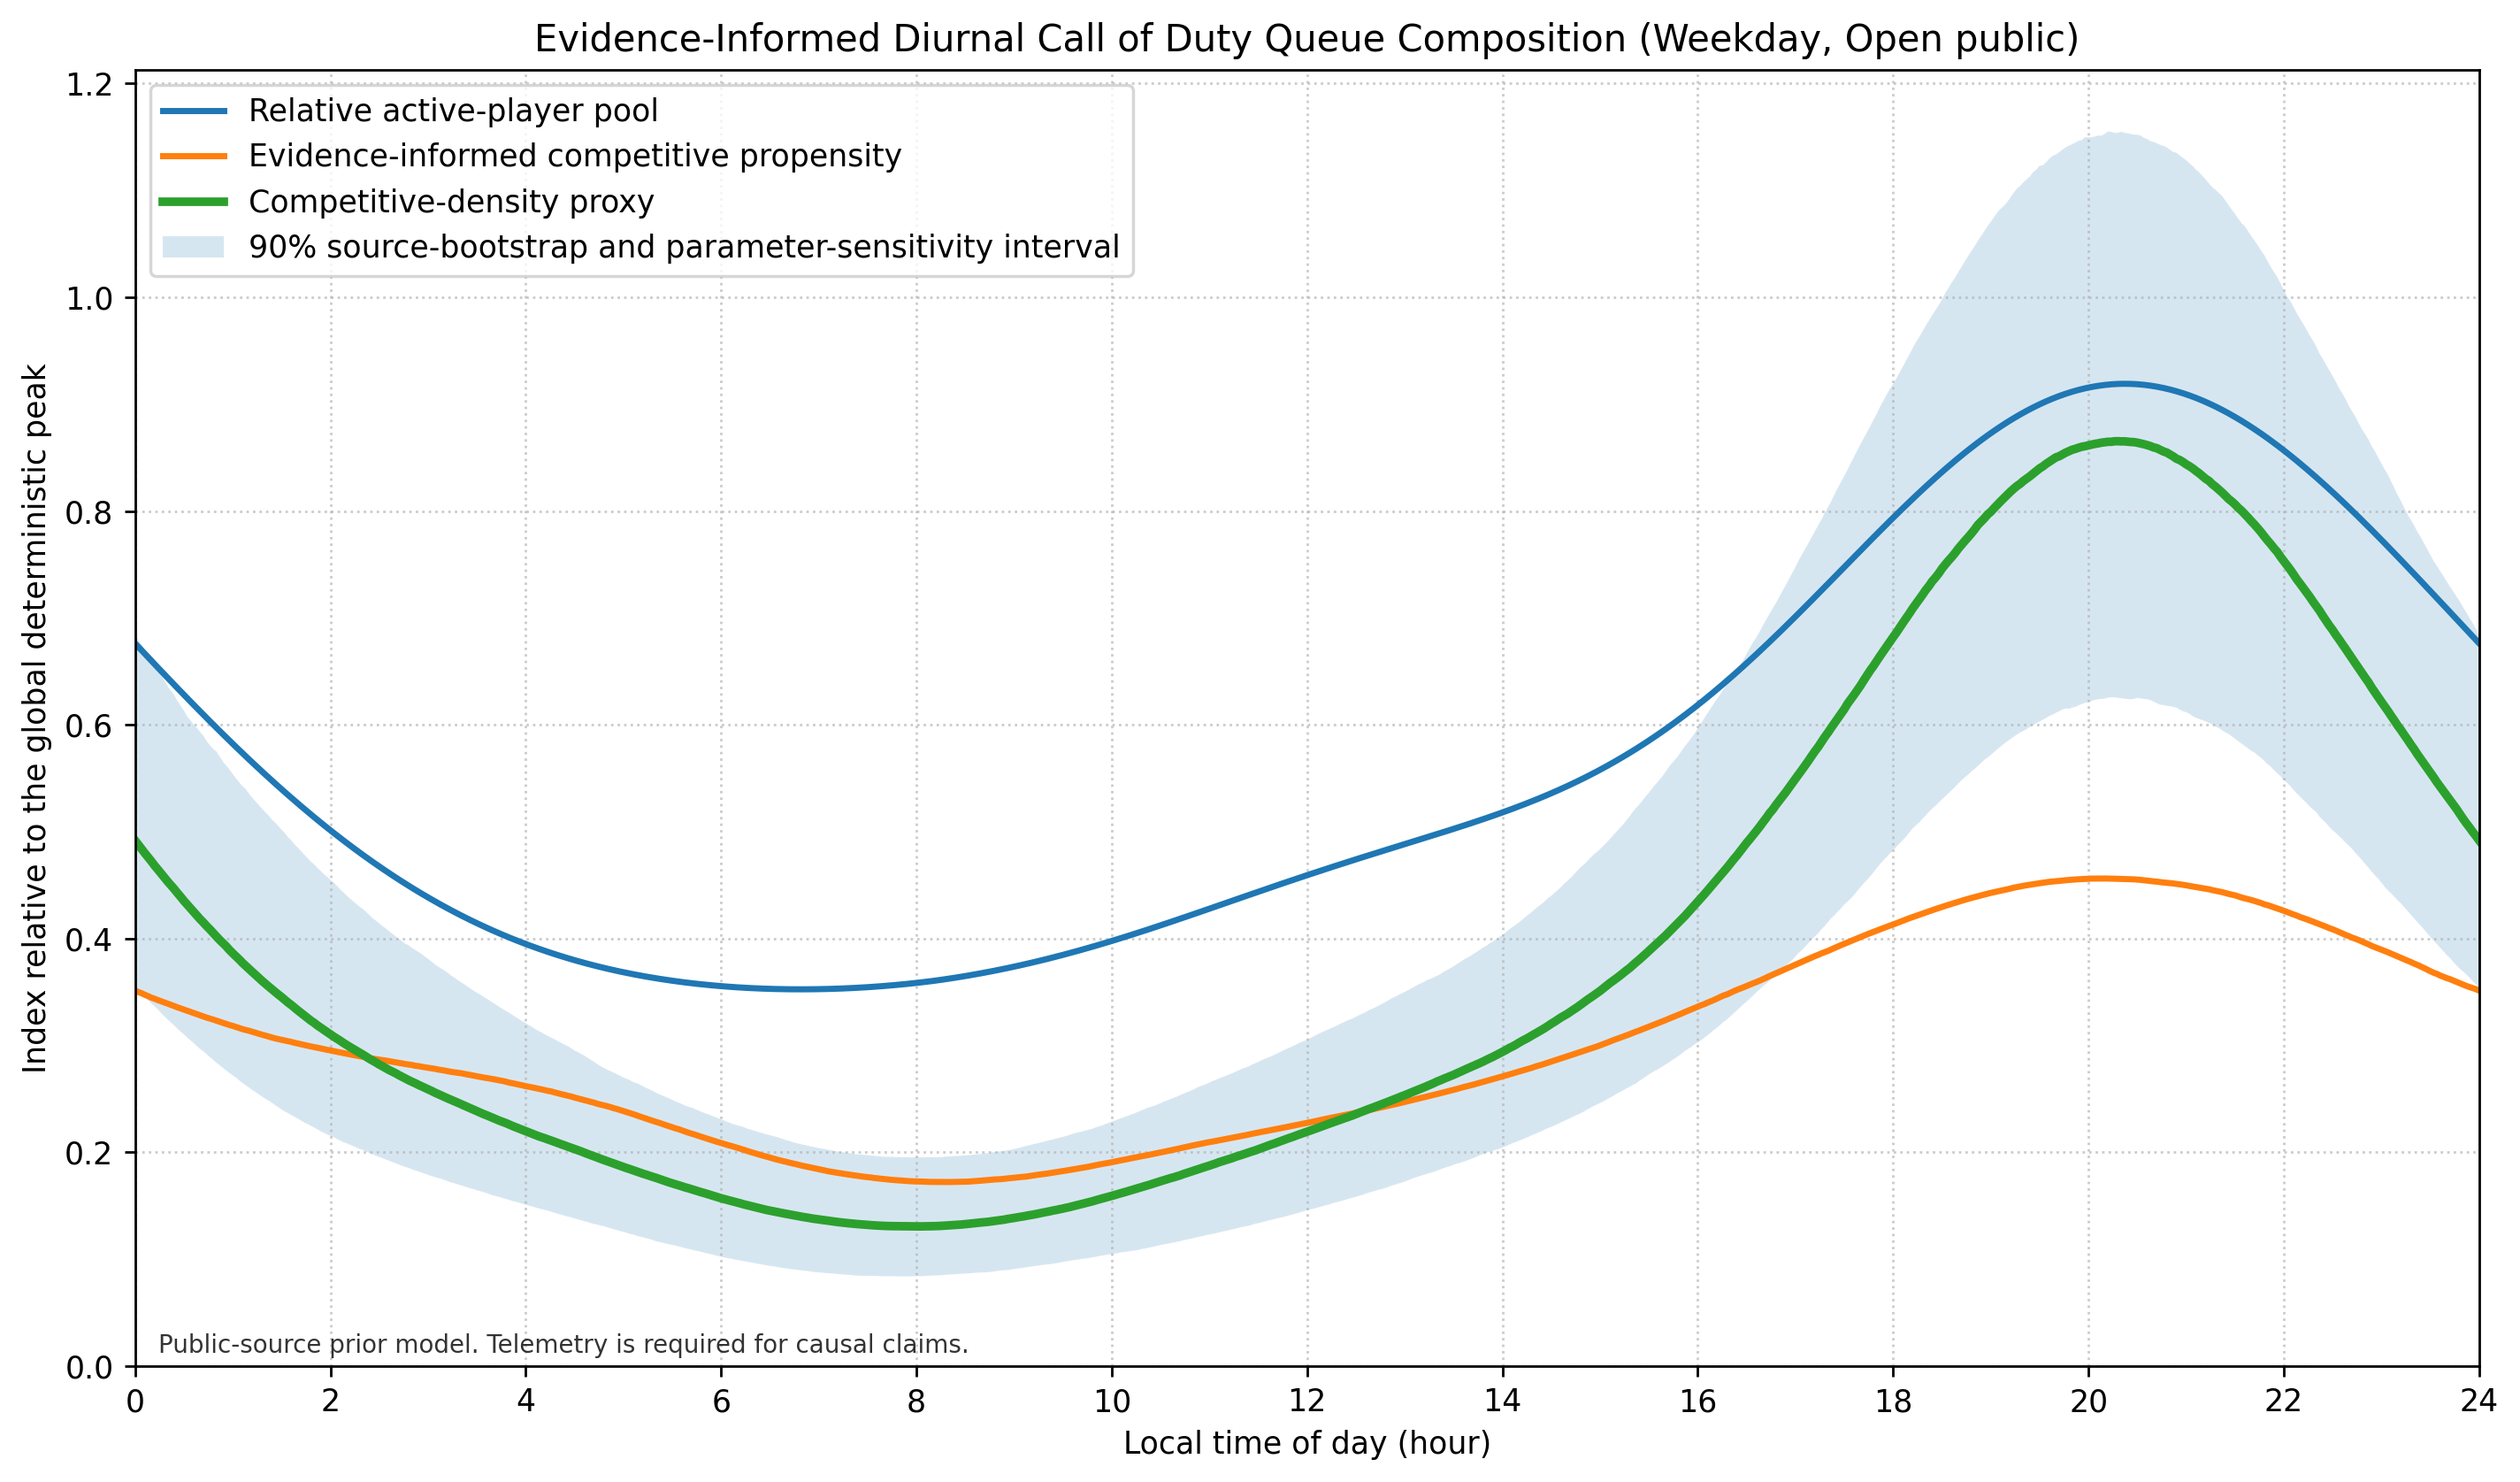

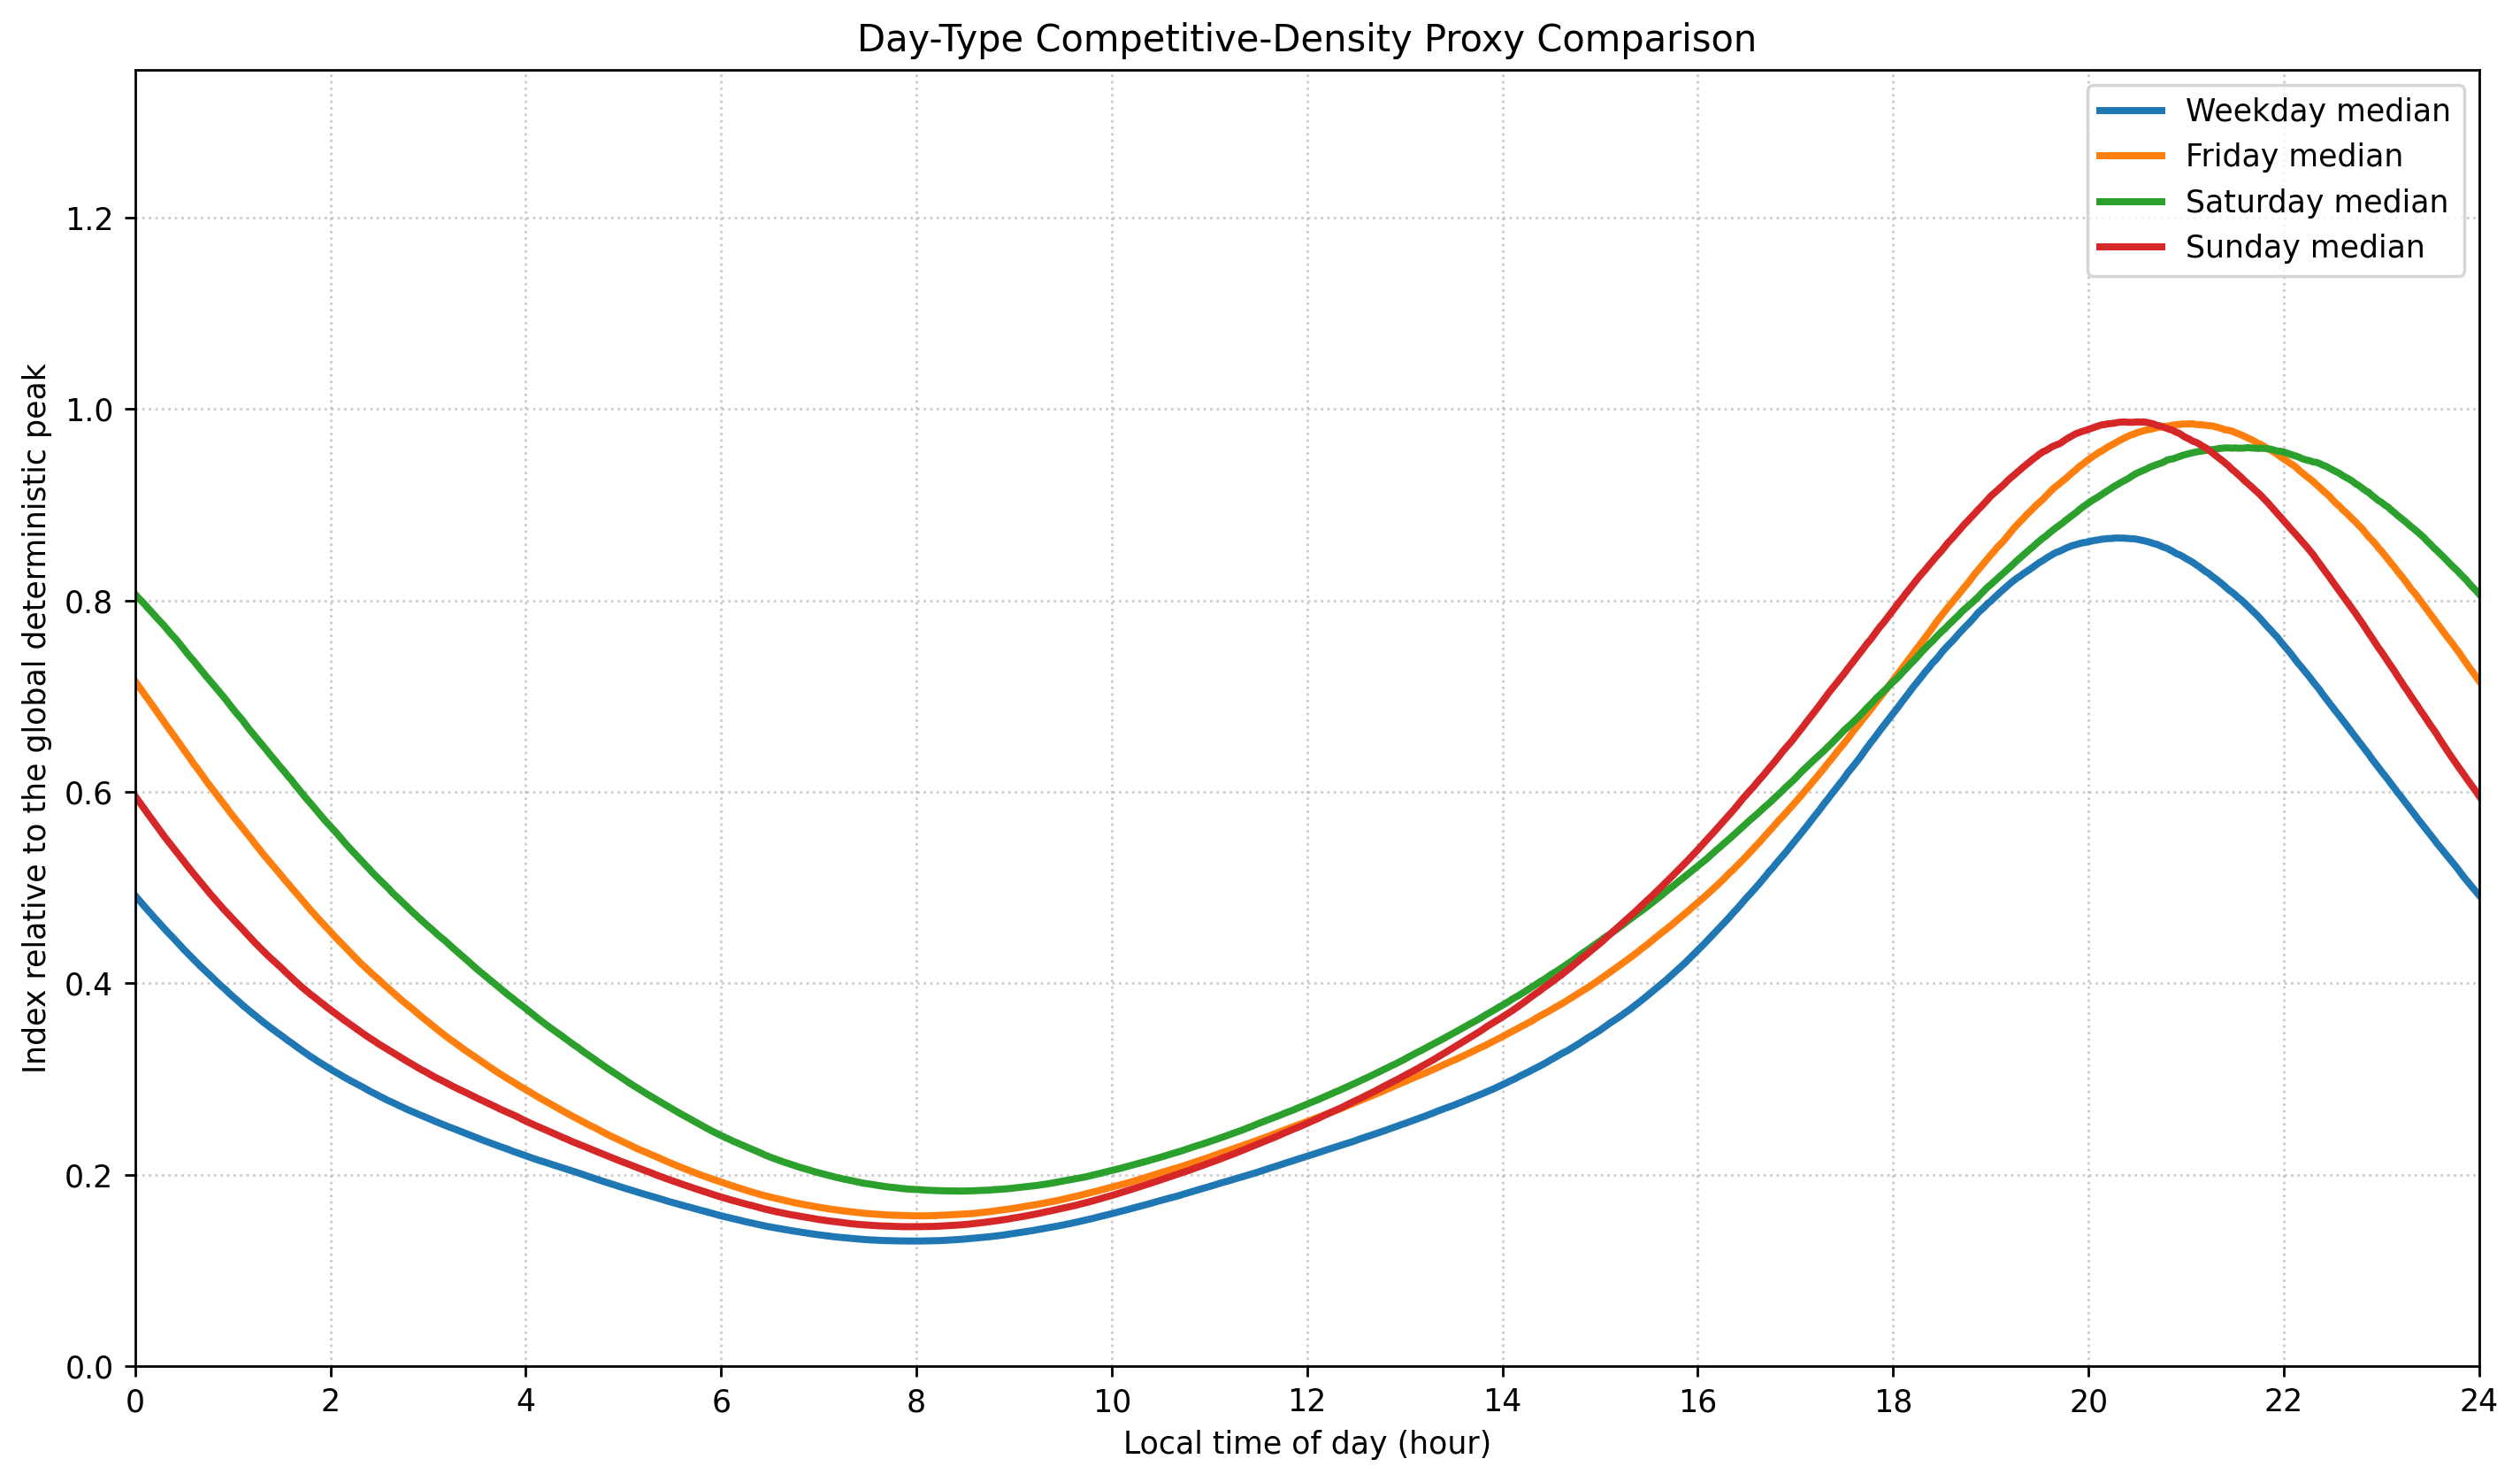

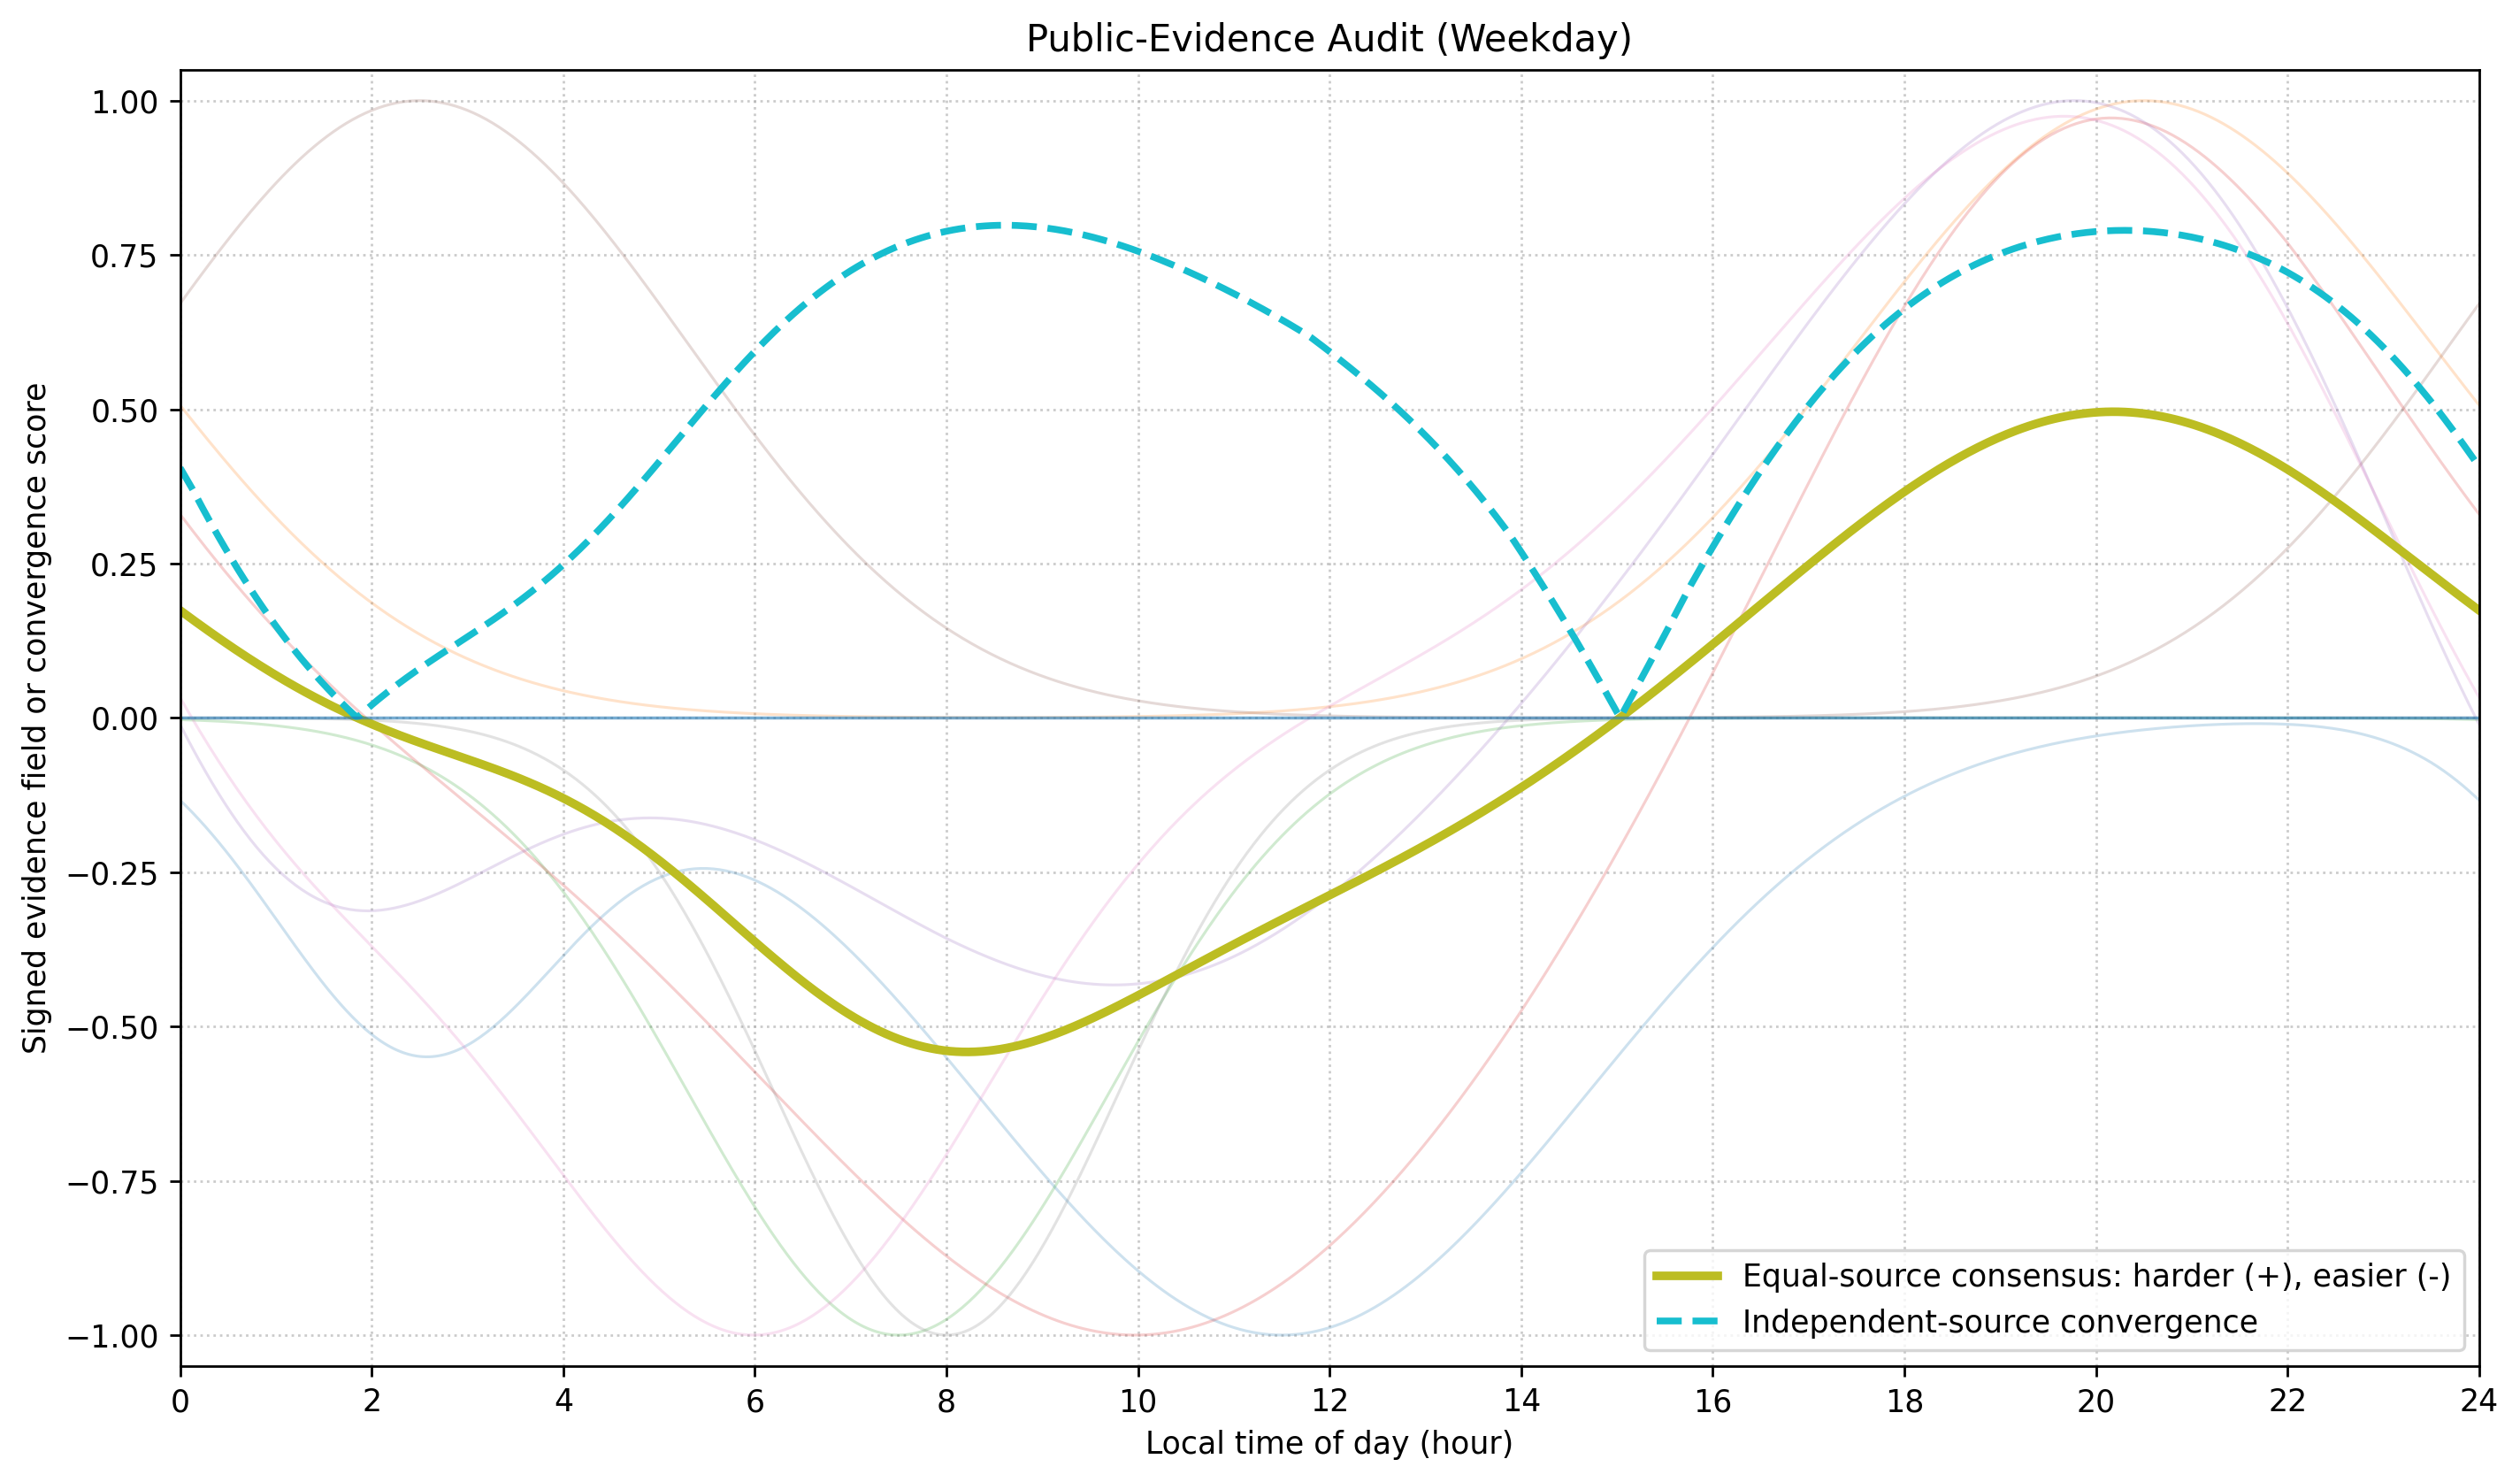

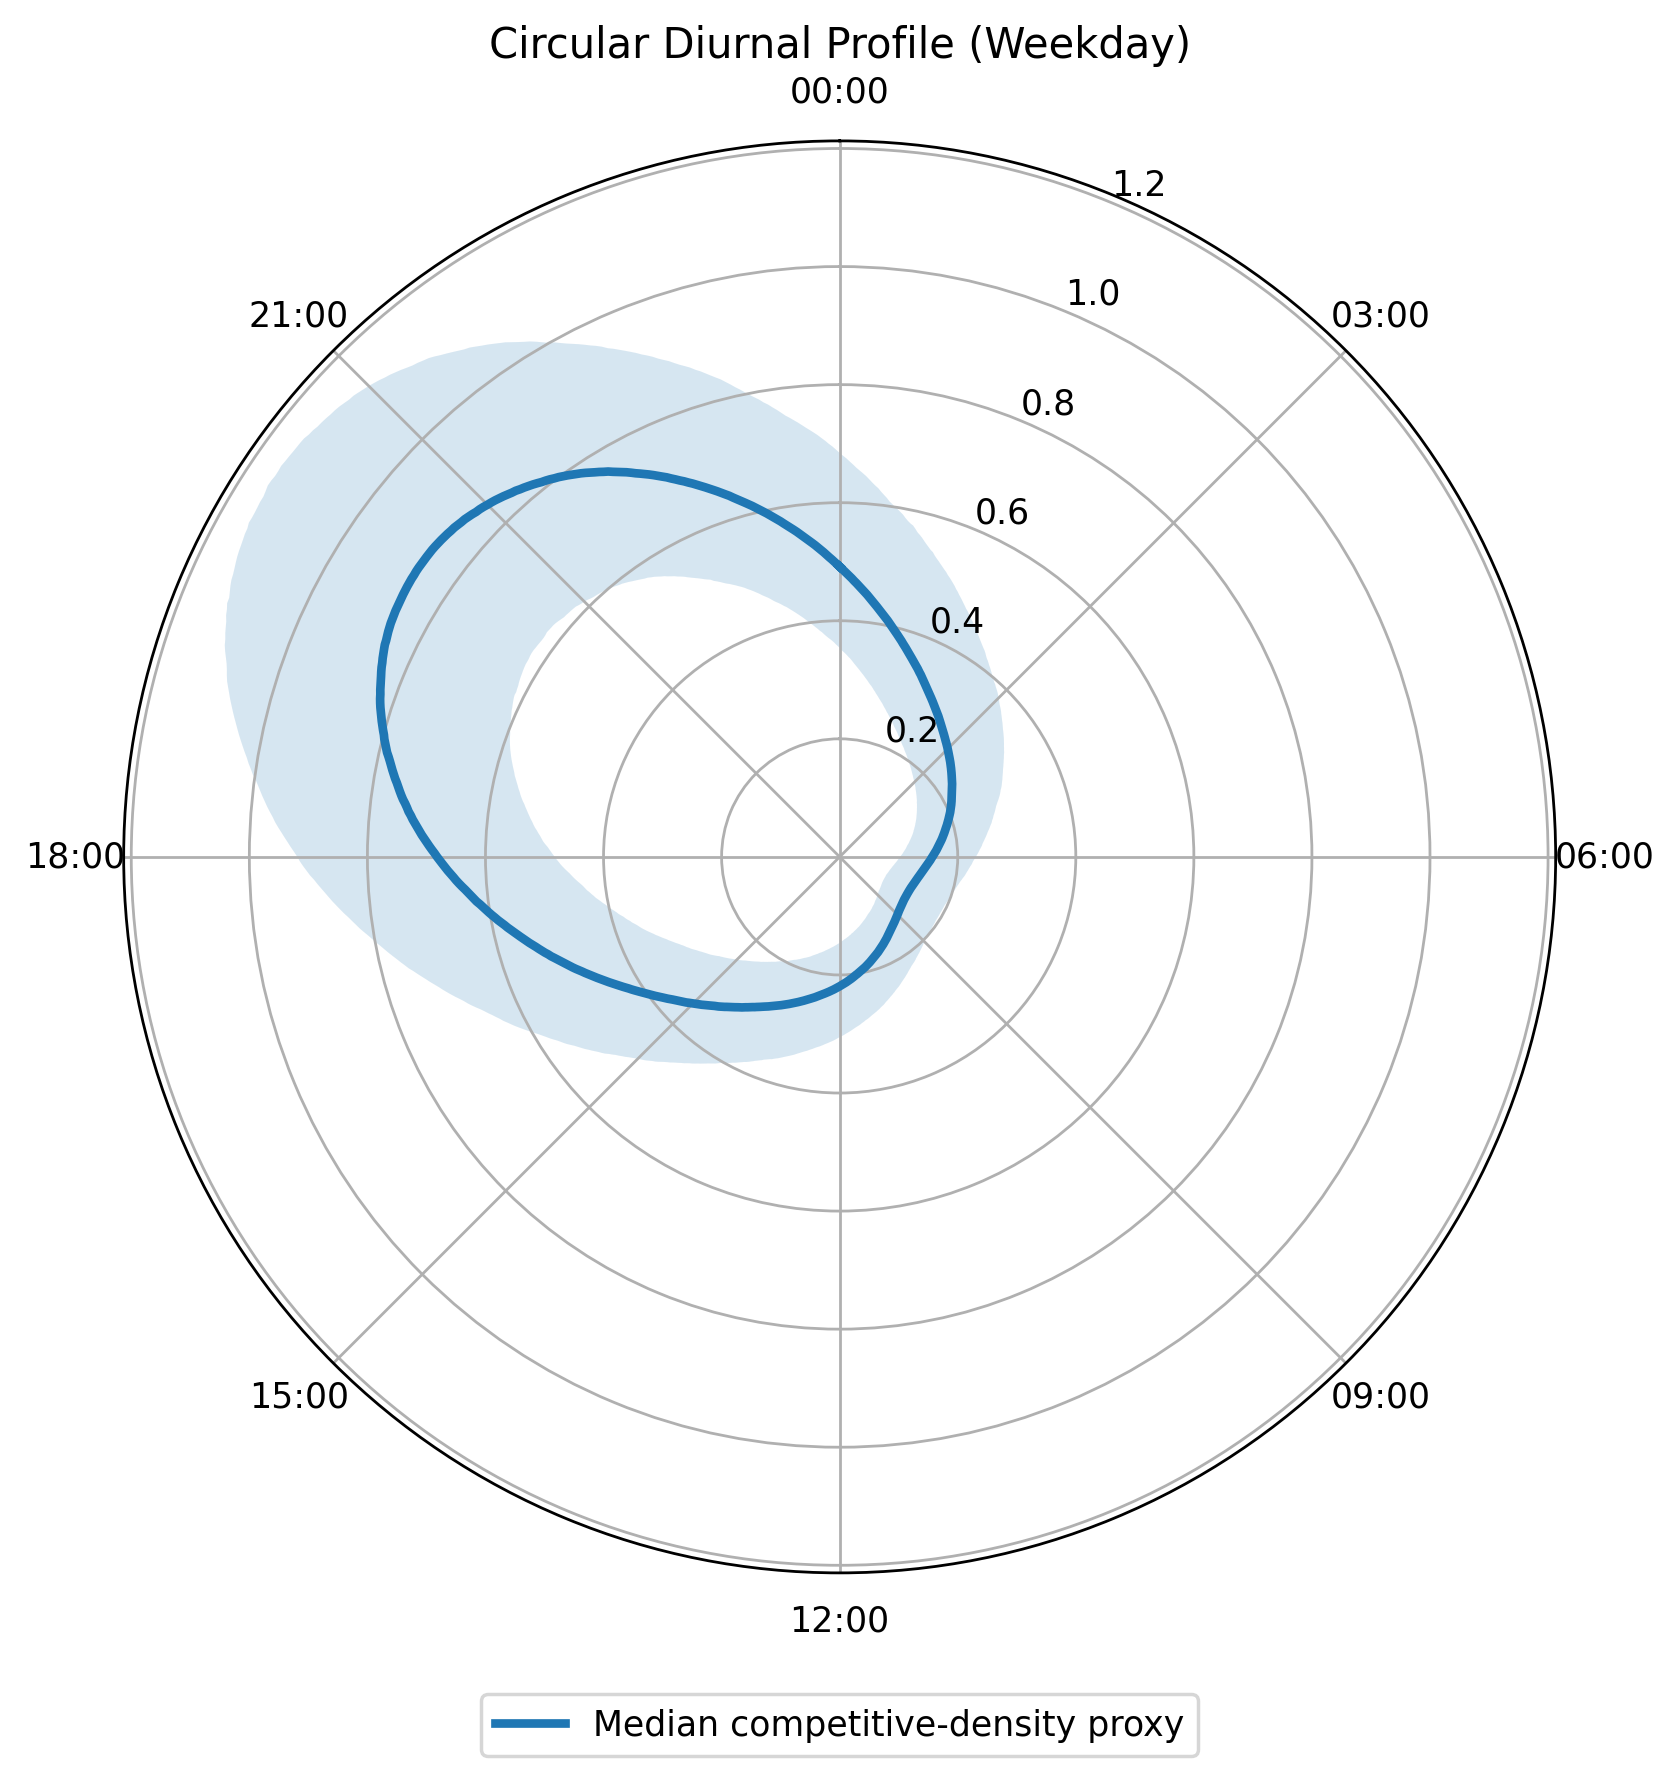

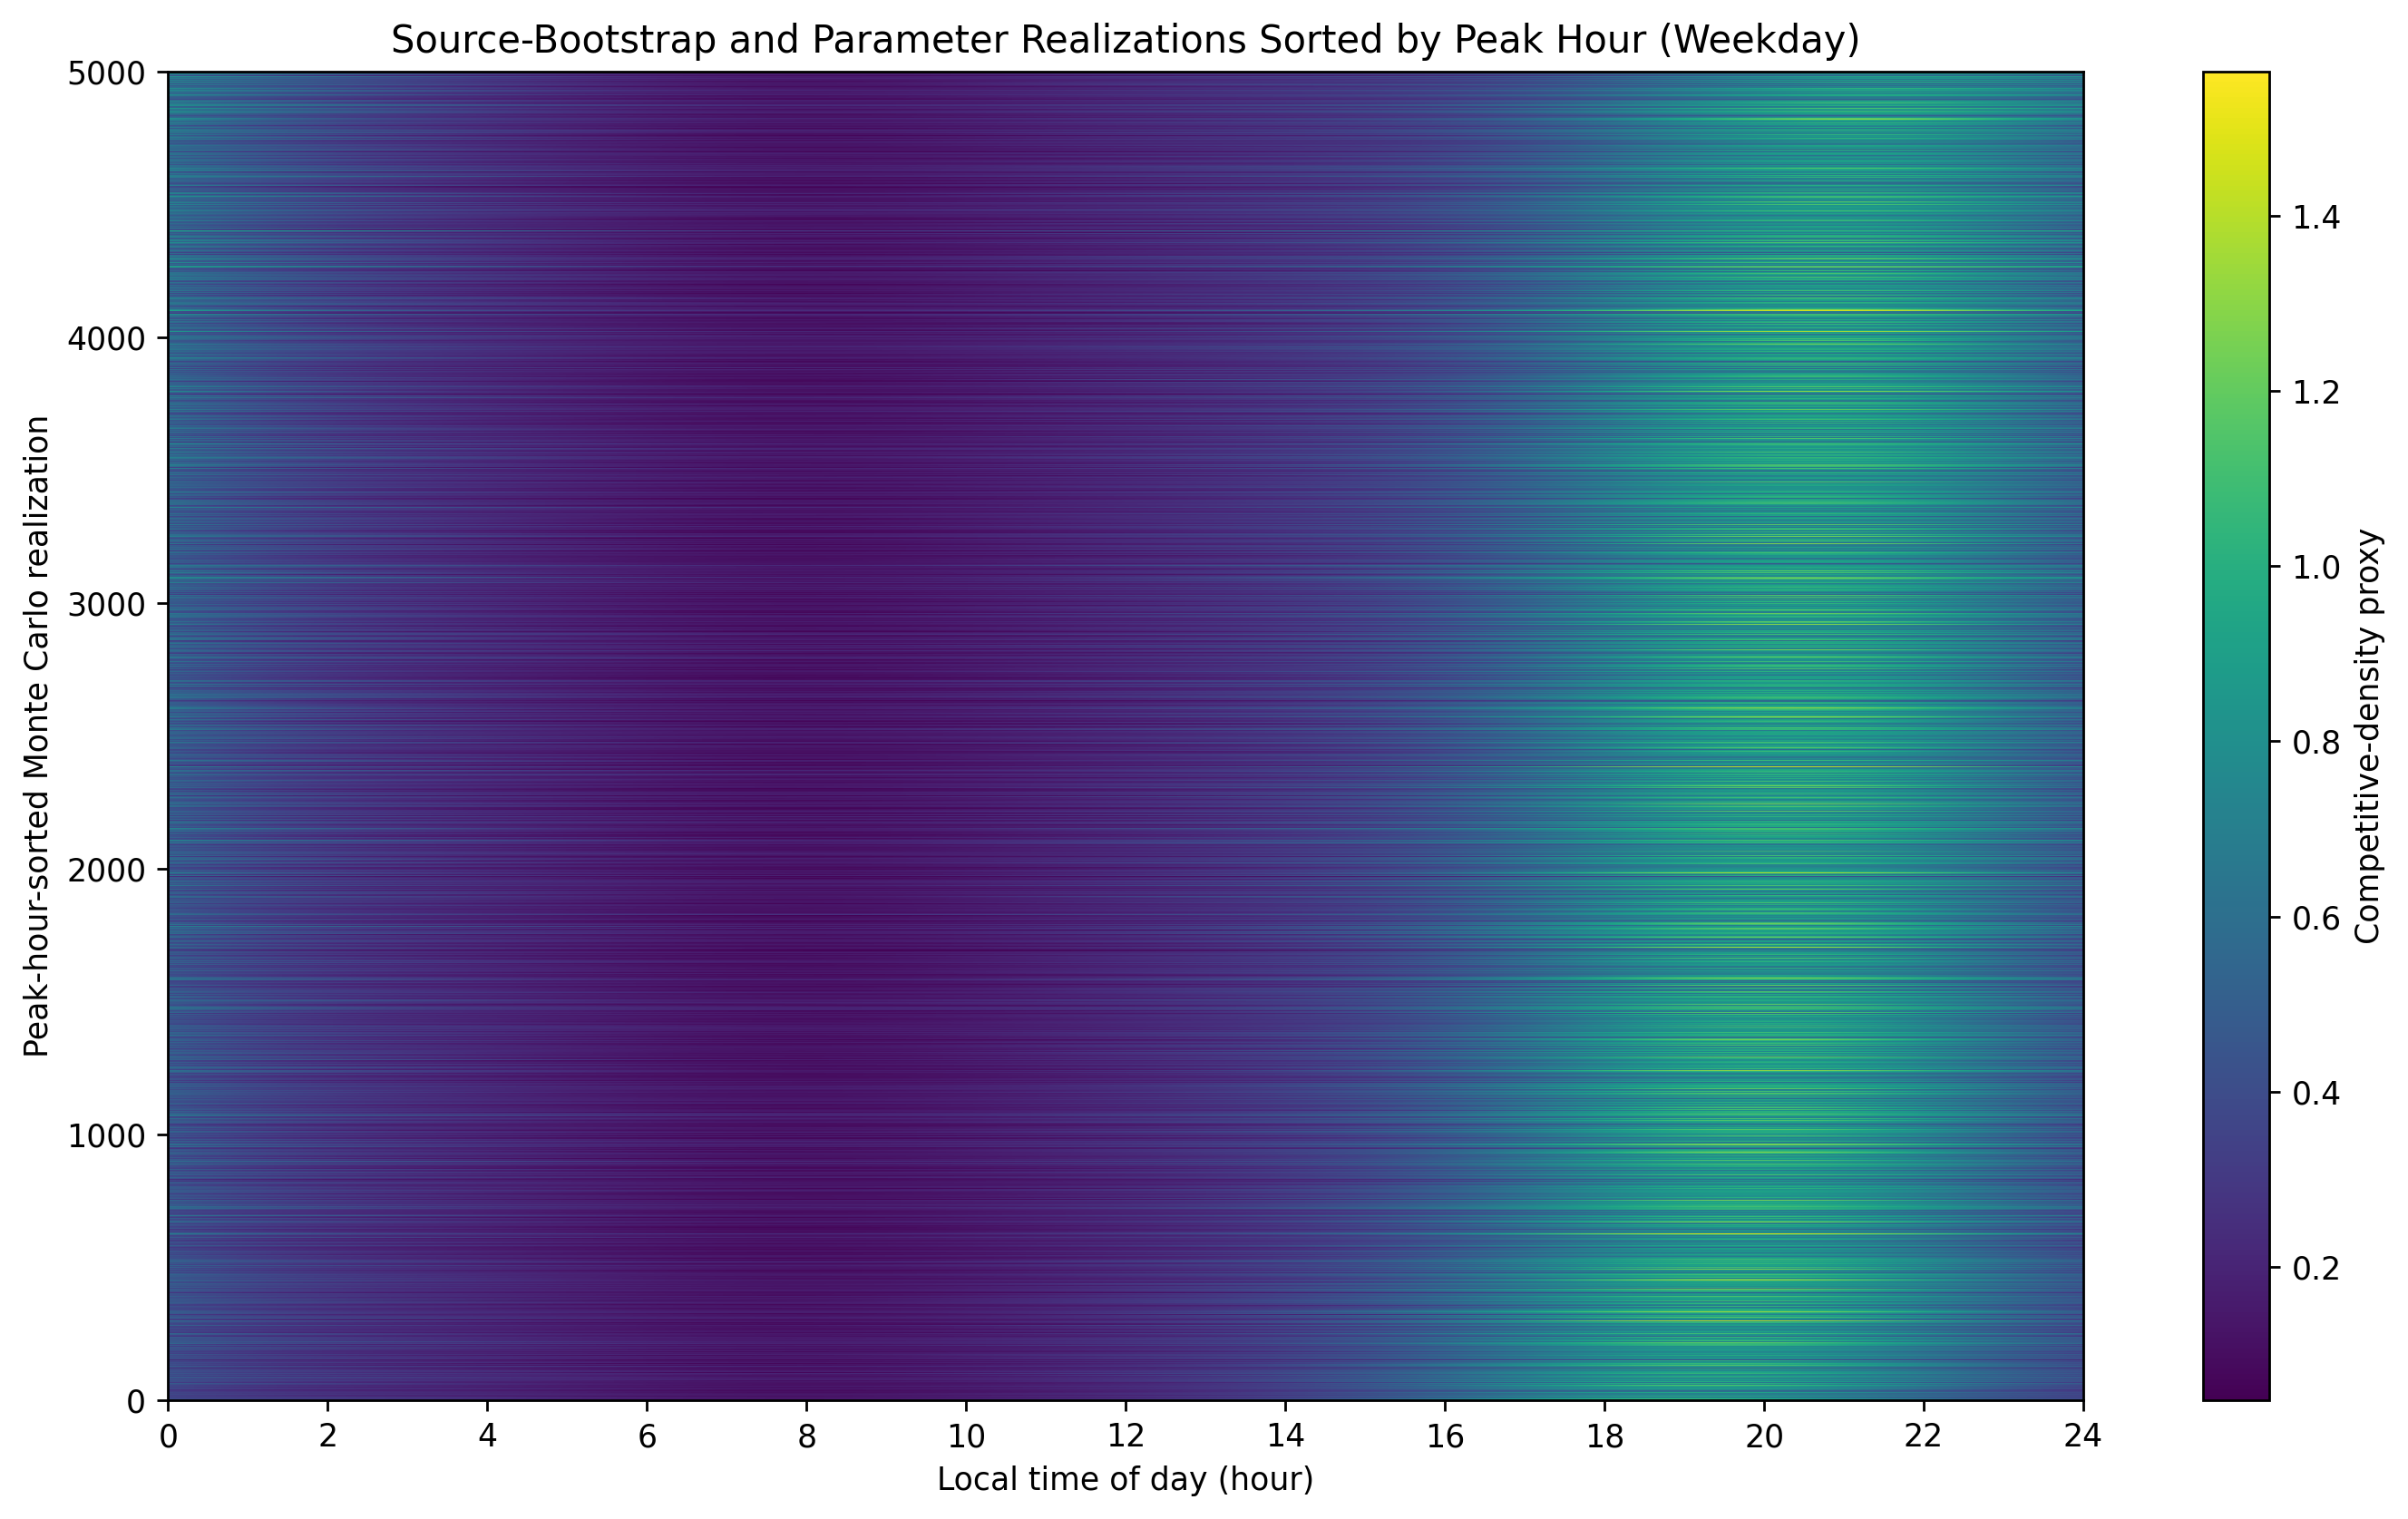

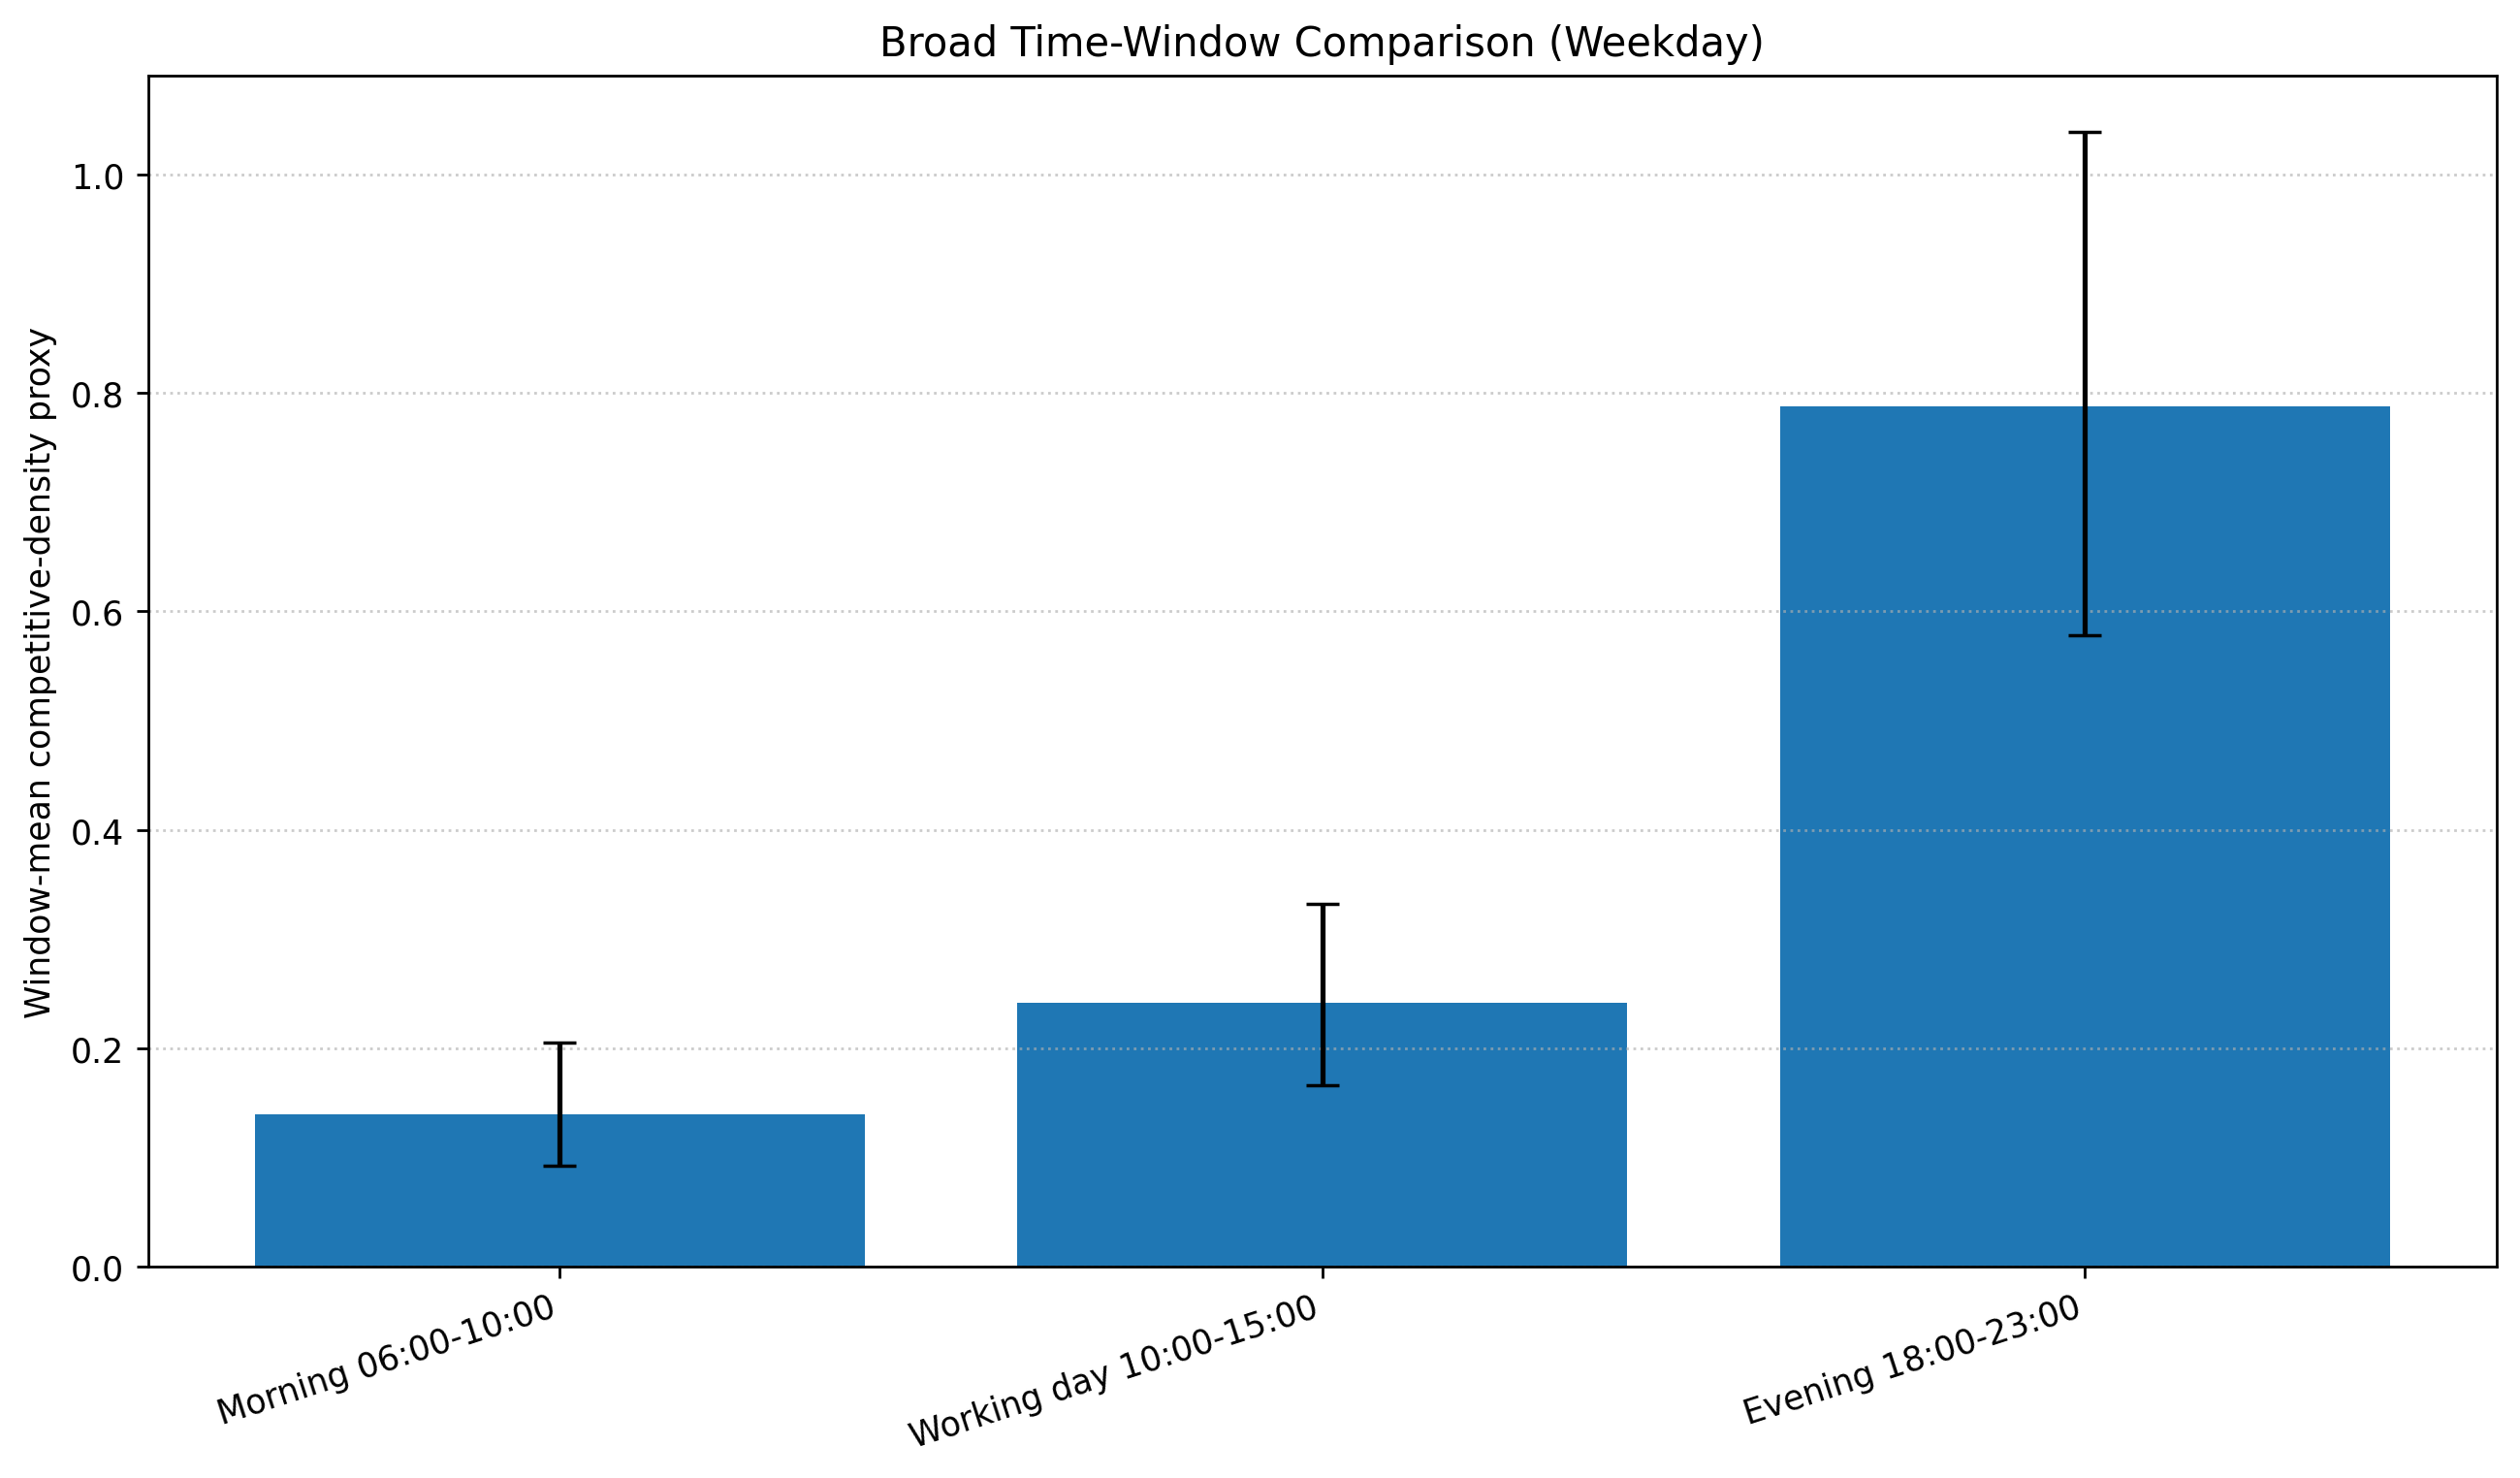

In [3]:
"""Model evidence-informed diurnal Call of Duty queue composition.

The model combines three distinct quantities on a circular 24-hour domain:

1. A relative active-player-pool prior for each day type.
2. A competitive-player propensity inferred from independent public discussion
   threads using a source-level Bayesian bootstrap.
3. A competitive-density proxy formed from activity and propensity.

The public evidence supports broad ordinal comparisons, such as evening versus
morning difficulty, more reliably than exact peak hours. The script therefore
reports broad time-window probabilities and labels all intervals as prior
sensitivity intervals.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------
HOURS_PER_DAY: Final = 24.0
NUM_TIME_POINTS: Final = 721
MONTE_CARLO_SAMPLES: Final = 5000
RANDOM_SEED: Final = 42
CENTRAL_INTERVAL: Final = 0.90

SELECTED_SCENARIO: Final = "Weekday"
SELECTED_MATCHMAKING_REGIME: Final = "Open public"

SHOW_DAY_TYPE_COMPARISON: Final = True
SHOW_EVIDENCE_AUDIT_PLOT: Final = True
SHOW_POLAR_PLOT: Final = True
SHOW_UNCERTAINTY_HEATMAP: Final = True
SHOW_WINDOW_COMPARISON: Final = True
PRINT_SOURCE_AUDIT: Final = True

# Modeling sensitivity. These are explicit scenario assumptions instead of
# published Activision coefficients.
MATCHMAKING_REGIME_MULTIPLIERS: Final = {
    "Open public": 1.00,
    "Skill-aware public": 0.78,
    "Ranked": 0.48,
}

# Activity-prior uncertainty.
PEAK_TIME_STD_HOURS: Final = 0.65
ACTIVITY_AMPLITUDE_REL_STD: Final = 0.12
ACTIVITY_WIDTH_REL_STD: Final = 0.10
ACTIVITY_BASELINE_REL_STD: Final = 0.12
MIN_STD_HOURS: Final = 0.40

# Evidence-to-propensity uncertainty.
PROPENSITY_BASELINE_PROBABILITY: Final = 0.30
PROPENSITY_BASELINE_LOGIT_STD: Final = 0.18
EVIDENCE_LOGIT_SCALE: Final = 1.35
EVIDENCE_LOGIT_SCALE_STD: Final = 0.20
SOURCE_BOOTSTRAP_CONCENTRATION: Final = 1.00

# Optional empirical data. Each activity file must contain local_hour and
# player_count. The difficulty file must contain local_hour and
# competitive_score. Empty mappings retain the built-in priors.
ACTIVITY_CSV_PATHS: dict[str, str] = {}
DIFFICULTY_CSV_PATH: str | None = None
OBSERVATION_BANDWIDTH_HOURS: Final = 1.25
EMPIRICAL_ACTIVITY_SHIFT_STD_HOURS: Final = 0.25
EMPIRICAL_ACTIVITY_SCALE_REL_STD: Final = 0.05
EMPIRICAL_ACTIVITY_CONTRAST_REL_STD: Final = 0.08

# Conservative broad windows used for auditable comparisons.
COMPARISON_WINDOWS: Final = {
    "Morning 06:00-10:00": (6.0, 10.0),
    "Working day 10:00-15:00": (10.0, 15.0),
    "Evening 18:00-23:00": (18.0, 23.0),
}

plt.rcParams.update(
    {
        "figure.dpi": 250,
        "font.family": "sans-serif",
        "font.sans-serif": ["Tahoma", "DejaVu Sans"],
        "font.weight": "normal",
    }
)

FloatArray = NDArray[np.float64]


@dataclass(frozen=True)
class Peak:
    """Define one circular Gaussian contribution to an activity profile."""

    label: str
    center_hour: float
    amplitude: float
    std_hours: float


@dataclass(frozen=True)
class DayScenario:
    """Define one day-type activity prior."""

    name: str
    activity_baseline: float
    activity_peaks: tuple[Peak, ...]


@dataclass(frozen=True)
class EvidenceClaim:
    """Represent one qualitative time-window claim from a public source.

    Attributes:
        label: Human-readable claim description.
        day_types: Day scenarios to which the claim applies.
        center_hour: Circular center of the reported time window.
        std_hours: Width of the soft time-window kernel.
        direction: Positive for harder and negative for easier reports.
        strength: Within-source claim specificity in the interval [0, 1].
    """

    label: str
    day_types: tuple[str, ...]
    center_hour: float
    std_hours: float
    direction: float
    strength: float


@dataclass(frozen=True)
class EvidenceSource:
    """Represent one independent public discussion thread."""

    source_id: str
    title: str
    url: str
    platform: str
    claims: tuple[EvidenceClaim, ...]


@dataclass(frozen=True)
class OfficialReference:
    """Store an official source that constrains model interpretation."""

    title: str
    url: str
    implication: str


@dataclass(frozen=True)
class EvidenceProfile:
    """Store deterministic evidence consensus and convergence diagnostics."""

    consensus: FloatArray
    convergence: FloatArray
    source_fields: FloatArray
    source_ids: tuple[str, ...]


@dataclass(frozen=True)
class DeterministicProfiles:
    """Store deterministic activity, propensity, and density profiles."""

    activity_raw: FloatArray
    activity: FloatArray
    competitive_propensity: FloatArray
    competitive_density_raw: FloatArray
    competitive_density: FloatArray
    evidence_consensus: FloatArray
    evidence_convergence: FloatArray


@dataclass(frozen=True)
class MonteCarloBands:
    """Store source-bootstrap and parameter-sensitivity results."""

    lower: FloatArray
    median: FloatArray
    upper: FloatArray
    samples: FloatArray
    propensity_lower: FloatArray
    propensity_median: FloatArray
    propensity_upper: FloatArray
    peak_hours: FloatArray


@dataclass(frozen=True)
class EmpiricalSeries:
    """Store local-hour observations and normalized values."""

    hours: FloatArray
    values: FloatArray


@dataclass(frozen=True)
class WindowComparison:
    """Store a probabilistic comparison between two broad time windows."""

    label: str
    probability: float
    median_difference: float
    median_ratio: float
    interpretation: str


# The activity priors are intentionally broad. They encode ordinary daily
# participation patterns and avoid asserting a precise measured concurrency
# curve. Empirical activity CSV data can replace each prior.
WEEKDAY_SCENARIO = DayScenario(
    name="Weekday",
    activity_baseline=0.38,
    activity_peaks=(
        Peak("Midday activity", 13.0, 0.12, 2.5),
        Peak("Evening activity", 20.2, 0.62, 3.1),
        Peak("Late-night tail", 0.6, 0.08, 2.5),
    ),
)

FRIDAY_SCENARIO = DayScenario(
    name="Friday",
    activity_baseline=0.40,
    activity_peaks=(
        Peak("Afternoon activity", 14.0, 0.15, 2.8),
        Peak("Evening activity", 21.0, 0.65, 3.4),
        Peak("Late-night tail", 0.8, 0.12, 2.8),
    ),
)

SATURDAY_SCENARIO = DayScenario(
    name="Saturday",
    activity_baseline=0.45,
    activity_peaks=(
        Peak("Afternoon activity", 15.0, 0.20, 3.4),
        Peak("Evening activity", 22.0, 0.55, 3.7),
        Peak("Late-night tail", 1.3, 0.15, 3.0),
    ),
)

SUNDAY_SCENARIO = DayScenario(
    name="Sunday",
    activity_baseline=0.42,
    activity_peaks=(
        Peak("Afternoon activity", 14.5, 0.18, 3.2),
        Peak("Evening activity", 20.5, 0.58, 3.2),
        Peak("Late-night tail", 0.4, 0.10, 2.7),
    ),
)

SCENARIOS: Final = {
    scenario.name: scenario
    for scenario in (
        WEEKDAY_SCENARIO,
        FRIDAY_SCENARIO,
        SATURDAY_SCENARIO,
        SUNDAY_SCENARIO,
    )
}

ALL_DAY_TYPES: Final = tuple(SCENARIOS)
WEEKEND_DAY_TYPES: Final = ("Friday", "Saturday", "Sunday")

# Each thread contributes at most one source-level field to the Bayesian
# bootstrap. Multiple comments from one thread therefore do not masquerade as
# independent evidence. Opposing claims remain in the same source field and
# reduce its net influence.
EVIDENCE_SOURCES: Final = (
    EvidenceSource(
        source_id="warzone_time_of_day_2024",
        title="Does time of day really make a difference?",
        url=(
            "https://www.reddit.com/r/CODWarzone/comments/"
            "1erqtn5/does_time_of_day_really_make_a_difference/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Daytime reported as easier",
                ALL_DAY_TYPES,
                11.5,
                3.2,
                -1.0,
                0.85,
            ),
            EvidenceClaim(
                "Weekend evenings reported as harder",
                WEEKEND_DAY_TYPES,
                21.0,
                2.6,
                1.0,
                0.90,
            ),
            EvidenceClaim(
                "Very late night sometimes reported as easier",
                ALL_DAY_TYPES,
                2.5,
                1.5,
                -1.0,
                0.45,
            ),
        ),
    ),
    EvidenceSource(
        source_id="warzone_sweatiest_hours_2025",
        title="What are the sweatiest hours?",
        url=(
            "https://www.reddit.com/r/CODWarzone/comments/"
            "1lmq5u8/what_are_the_sweatiest_hours/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Friday and Saturday after 23:00 reported as harder",
                ("Friday", "Saturday"),
                0.5,
                2.0,
                1.0,
                0.80,
            ),
            EvidenceClaim(
                "Saturday early morning reported as harder by some users",
                ("Saturday",),
                7.0,
                2.0,
                1.0,
                0.40,
            ),
        ),
    ),
    EvidenceSource(
        source_id="warzone_low_kd_2024",
        title="Question for sub-0.8-KD players at different times",
        url=(
            "https://www.reddit.com/r/CODWarzone/comments/"
            "1gzshkq/question_for_sub_8kd_players_who_play_at/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Matches after 18:00 reported as harder",
                ALL_DAY_TYPES,
                20.5,
                3.0,
                1.0,
                0.80,
            ),
        ),
    ),
    EvidenceSource(
        source_id="warzone_early_morning_2022",
        title="Want easy lobbies? Wake up early",
        url=(
            "https://www.reddit.com/r/CODWarzone/comments/"
            "wo9v1x/want_easy_lobbies_wake_up_early/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Early morning reported as easier",
                ALL_DAY_TYPES,
                7.5,
                2.2,
                -1.0,
                0.85,
            ),
        ),
    ),
    EvidenceSource(
        source_id="warzone_streamer_lobbies_2021",
        title="How do top players get lower-KD lobbies?",
        url=(
            "https://www.reddit.com/r/CODWarzone/comments/"
            "r1smqz/how_does_the_top_players_getting_lobbies_around/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Morning and working-day matches reported as easier",
                ALL_DAY_TYPES,
                10.0,
                3.8,
                -1.0,
                0.90,
            ),
            EvidenceClaim(
                "Weekday evening matches reported as harder",
                ("Weekday", "Friday"),
                20.0,
                2.8,
                1.0,
                0.90,
            ),
            EvidenceClaim(
                "Weekend matches reported as harder",
                WEEKEND_DAY_TYPES,
                18.5,
                5.0,
                1.0,
                0.75,
            ),
        ),
    ),
    EvidenceSource(
        source_id="bo6_morning_evening_2025",
        title="Morning vs evening lobbies: what is going on?",
        url=(
            "https://www.reddit.com/r/blackops6/comments/"
            "1lmbeke/morning_vs_evening_lobbies_whats_going_on/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "06:00-15:00 reported as easier by the original poster",
                ALL_DAY_TYPES,
                10.5,
                3.0,
                -1.0,
                0.85,
            ),
            EvidenceClaim(
                "After 16:00 reported as harder by the original poster",
                ALL_DAY_TYPES,
                20.0,
                3.2,
                1.0,
                0.85,
            ),
            EvidenceClaim(
                "Opposing daytime-hard report in the same thread",
                ALL_DAY_TYPES,
                11.0,
                3.0,
                1.0,
                0.50,
            ),
            EvidenceClaim(
                "Opposing post-23:00-easier report in the same thread",
                ALL_DAY_TYPES,
                1.0,
                2.0,
                -1.0,
                0.45,
            ),
        ),
    ),
    EvidenceSource(
        source_id="bo6_late_night_2025",
        title="Does matchmaking get sweaty late night or dawn?",
        url=(
            "https://www.reddit.com/r/blackops6/comments/"
            "1l6xzuq/does_matchmaking_get_super_sweaty_late_nightdawn/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Late night and dawn reported as harder",
                ALL_DAY_TYPES,
                2.5,
                2.8,
                1.0,
                0.65,
            ),
        ),
    ),
    EvidenceSource(
        source_id="bo6_peak_offpeak_2025",
        title="Difference between peak and off-peak play",
        url=(
            "https://www.reddit.com/r/blackops6/comments/"
            "1jhz07g/the_sheer_difference_in_playing_this_game_during/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Early morning reported as easier",
                ALL_DAY_TYPES,
                6.0,
                2.4,
                -1.0,
                0.80,
            ),
            EvidenceClaim(
                "Evenings and weekends reported as harder",
                ALL_DAY_TYPES,
                20.0,
                3.4,
                1.0,
                0.80,
            ),
            EvidenceClaim(
                "A late session reported as enjoyable in the same thread",
                ALL_DAY_TYPES,
                0.5,
                2.0,
                -1.0,
                0.35,
            ),
        ),
    ),
    EvidenceSource(
        source_id="warzone_casual_2025",
        title="Best time of day to play casually",
        url=(
            "https://www.reddit.com/r/Warzone/comments/"
            "1nb3red/best_time_to_play_for_casual/"
        ),
        platform="Reddit",
        claims=(
            EvidenceClaim(
                "Around 08:00 reported as easier",
                ALL_DAY_TYPES,
                8.0,
                1.8,
                -1.0,
                0.60,
            ),
        ),
    ),
)

OFFICIAL_REFERENCES: Final = (
    OfficialReference(
        title="Call of Duty Matchmaking Intel, White Paper 2",
        url=(
            "https://research.activision.com/publications/2024/07/"
            "Call-of-Duty-Matchmaking-Intel-02"
        ),
        implication=(
            "Connection and time to match are top priorities; skill also "
            "enters lobby formation and team balancing."
        ),
    ),
    OfficialReference(
        title="Black Ops 7 Beta Patch Notes",
        url=(
            "https://www.callofduty.com/patchnotes/2025/10/"
            "call-of-duty-black-ops-7-beta-patch-notes"
        ),
        implication=(
            "Open matchmaking with minimal skill consideration was announced "
            "as the default for Black Ops 7 Multiplayer at launch."
        ),
    ),
    OfficialReference(
        title="Black Ops 7 Warzone Season 01 Patch Notes",
        url=(
            "https://www.callofduty.com/patchnotes/2025/12/"
            "call-of-duty-bo7-warzone-season-01-patch-notes"
        ),
        implication=(
            "Open matchmaking with minimal skill consideration was introduced "
            "to Warzone public playlists."
        ),
    ),
)


def circular_difference(
    hours: FloatArray,
    center_hour: float | FloatArray,
) -> FloatArray:
    """Return signed shortest distances on a circular 24-hour domain."""
    half_day = HOURS_PER_DAY / 2.0
    return (hours - center_hour + half_day) % HOURS_PER_DAY - half_day


def circular_gaussian(
    hours: FloatArray,
    center_hour: float,
    std_hours: float,
) -> FloatArray:
    """Evaluate a Gaussian kernel with exact midnight continuity."""
    if std_hours <= 0.0:
        raise ValueError("std_hours must be positive.")
    delta = circular_difference(hours, center_hour)
    return np.exp(-0.5 * np.square(delta / std_hours))


def stable_sigmoid(values: FloatArray) -> FloatArray:
    """Evaluate a numerically stable logistic sigmoid."""
    result = np.empty_like(values, dtype=np.float64)
    nonnegative = values >= 0.0
    result[nonnegative] = 1.0 / (1.0 + np.exp(-values[nonnegative]))
    exponential = np.exp(values[~nonnegative])
    result[~nonnegative] = exponential / (1.0 + exponential)
    return result


def probability_to_logit(probability: float) -> float:
    """Convert a probability in the open interval (0, 1) to a logit."""
    if not 0.0 < probability < 1.0:
        raise ValueError("probability must lie strictly between zero and one.")
    return float(np.log(probability / (1.0 - probability)))


def normalize_by_reference(
    values: FloatArray,
    reference_scale: float,
) -> FloatArray:
    """Normalize values using a common positive reference scale."""
    if reference_scale <= 0.0:
        raise ValueError("reference_scale must be positive.")
    return values / reference_scale


def evaluate_activity_prior(
    hours: FloatArray,
    scenario: DayScenario,
) -> FloatArray:
    """Evaluate an unnormalized deterministic activity prior."""
    profile = np.full_like(
        hours,
        scenario.activity_baseline,
        dtype=np.float64,
    )
    for peak in scenario.activity_peaks:
        profile += peak.amplitude * circular_gaussian(
            hours,
            peak.center_hour,
            peak.std_hours,
        )
    return profile


def normalize_source_field(field: FloatArray) -> FloatArray:
    """Normalize one source field to unit maximum absolute magnitude."""
    maximum = float(np.max(np.abs(field)))
    if maximum <= np.finfo(float).eps:
        return np.zeros_like(field)
    return field / maximum


def build_source_fields(
    hours: FloatArray,
    day_type: str,
) -> tuple[FloatArray, tuple[str, ...]]:
    """Build one signed evidence field per independent source thread."""
    fields: list[FloatArray] = []
    source_ids: list[str] = []

    for source in EVIDENCE_SOURCES:
        field = np.zeros_like(hours, dtype=np.float64)
        for claim in source.claims:
            if day_type not in claim.day_types:
                continue
            field += (
                claim.direction
                * claim.strength
                * circular_gaussian(
                    hours,
                    claim.center_hour,
                    claim.std_hours,
                )
            )

        if np.max(np.abs(field)) <= np.finfo(float).eps:
            continue

        fields.append(normalize_source_field(field))
        source_ids.append(source.source_id)

    if not fields:
        raise ValueError(f"No evidence sources apply to {day_type}.")

    return np.vstack(fields), tuple(source_ids)


def compute_evidence_profile(
    hours: FloatArray,
    day_type: str,
) -> EvidenceProfile:
    """Compute equal-source consensus and local convergence diagnostics."""
    source_fields, source_ids = build_source_fields(hours, day_type)
    consensus = np.mean(source_fields, axis=0)

    absolute_support = np.sum(np.abs(source_fields), axis=0)
    signed_support = np.abs(np.sum(source_fields, axis=0))
    agreement = np.divide(
        signed_support,
        absolute_support,
        out=np.zeros_like(signed_support),
        where=absolute_support > np.finfo(float).eps,
    )

    # Coverage approaches one as more independent source fields contribute.
    coverage = 1.0 - np.exp(-absolute_support / 2.5)
    convergence = agreement * coverage

    return EvidenceProfile(
        consensus=consensus,
        convergence=convergence,
        source_fields=source_fields,
        source_ids=source_ids,
    )


def compute_deterministic_raw_profiles(
    hours: FloatArray,
    scenario: DayScenario,
    regime_multiplier: float,
) -> tuple[FloatArray, FloatArray, FloatArray, EvidenceProfile]:
    """Compute deterministic raw profiles before common normalization."""
    activity_raw = evaluate_activity_prior(hours, scenario)
    evidence = compute_evidence_profile(hours, scenario.name)

    baseline_logit = probability_to_logit(
        PROPENSITY_BASELINE_PROBABILITY
    )
    propensity_logit = (
        baseline_logit
        + EVIDENCE_LOGIT_SCALE
        * regime_multiplier
        * evidence.consensus
    )
    propensity = stable_sigmoid(propensity_logit)
    density_raw = activity_raw * propensity
    return activity_raw, propensity, density_raw, evidence


def sample_positive_normal(
    rng: np.random.Generator,
    mean: float,
    relative_std: float,
    size: int,
    minimum: float,
) -> FloatArray:
    """Draw clipped positive normal samples."""
    std = max(abs(mean) * relative_std, np.finfo(float).eps)
    samples = rng.normal(mean, std, size=size)
    return np.clip(samples, minimum, None)


def evaluate_sampled_activity(
    hours: FloatArray,
    scenario: DayScenario,
    rng: np.random.Generator,
    num_samples: int,
) -> FloatArray:
    """Evaluate activity-prior Monte Carlo realizations."""
    baselines = sample_positive_normal(
        rng,
        scenario.activity_baseline,
        ACTIVITY_BASELINE_REL_STD,
        num_samples,
        0.0,
    )
    profiles = np.repeat(baselines[:, np.newaxis], hours.size, axis=1)
    hour_grid = hours[np.newaxis, :]

    for peak in scenario.activity_peaks:
        centers = (
            rng.normal(
                peak.center_hour,
                PEAK_TIME_STD_HOURS,
                size=num_samples,
            )
            % HOURS_PER_DAY
        )
        amplitudes = sample_positive_normal(
            rng,
            peak.amplitude,
            ACTIVITY_AMPLITUDE_REL_STD,
            num_samples,
            0.0,
        )
        widths = sample_positive_normal(
            rng,
            peak.std_hours,
            ACTIVITY_WIDTH_REL_STD,
            num_samples,
            MIN_STD_HOURS,
        )

        delta = circular_difference(
            hour_grid,
            centers[:, np.newaxis],
        )
        kernels = np.exp(
            -0.5 * np.square(delta / widths[:, np.newaxis])
        )
        profiles += amplitudes[:, np.newaxis] * kernels

    return profiles


def evaluate_sampled_empirical_activity(
    hours: FloatArray,
    activity_template: FloatArray,
    rng: np.random.Generator,
    num_samples: int,
) -> FloatArray:
    """Perturb a periodic empirical activity template in Fourier space.

    The perturbations represent timing, overall-scale, and contrast
    sensitivity. They preserve the measured template shape more faithfully
    than reverting to the built-in Gaussian activity prior.
    """
    if activity_template.shape != hours.shape:
        raise ValueError("activity_template must match the hour grid.")

    base = np.asarray(activity_template[:-1], dtype=np.float64)
    time_step = float(hours[1] - hours[0])
    frequencies = np.fft.rfftfreq(base.size, d=time_step)
    spectrum = np.fft.rfft(base)

    shifts = rng.normal(
        0.0,
        EMPIRICAL_ACTIVITY_SHIFT_STD_HOURS,
        size=num_samples,
    )
    phase = np.exp(
        -2.0j * np.pi * shifts[:, np.newaxis] * frequencies[np.newaxis, :]
    )
    shifted = np.fft.irfft(
        spectrum[np.newaxis, :] * phase,
        n=base.size,
        axis=1,
    )

    minimum = float(np.min(base))
    maximum = float(np.max(base))
    span = maximum - minimum
    if span <= np.finfo(float).eps:
        raise ValueError("Empirical activity template must vary.")

    normalized = np.clip((shifted - minimum) / span, 0.0, 1.0)
    contrast = sample_positive_normal(
        rng,
        1.0,
        EMPIRICAL_ACTIVITY_CONTRAST_REL_STD,
        num_samples,
        0.25,
    )
    adjusted = minimum + span * np.power(
        normalized,
        contrast[:, np.newaxis],
    )
    scale = sample_positive_normal(
        rng,
        1.0,
        EMPIRICAL_ACTIVITY_SCALE_REL_STD,
        num_samples,
        0.25,
    )
    adjusted *= scale[:, np.newaxis]

    return np.concatenate((adjusted, adjusted[:, :1]), axis=1)


def bayesian_bootstrap_evidence(
    evidence: EvidenceProfile,
    rng: np.random.Generator,
    num_samples: int,
) -> FloatArray:
    """Bootstrap independent source fields with Dirichlet weights."""
    num_sources = evidence.source_fields.shape[0]
    concentration = np.full(
        num_sources,
        SOURCE_BOOTSTRAP_CONCENTRATION,
        dtype=np.float64,
    )
    weights = rng.dirichlet(concentration, size=num_samples)
    return weights @ evidence.source_fields


def simulate_competitive_density(
    hours: FloatArray,
    scenario: DayScenario,
    evidence: EvidenceProfile,
    activity_template: FloatArray | None,
    activity_reference_scale: float,
    density_reference_scale: float,
    regime_multiplier: float,
    rng: np.random.Generator,
    num_samples: int,
) -> MonteCarloBands:
    """Propagate activity, source, and evidence-scale uncertainty."""
    if activity_template is None:
        activity_raw = evaluate_sampled_activity(
            hours,
            scenario,
            rng,
            num_samples,
        )
    else:
        activity_raw = evaluate_sampled_empirical_activity(
            hours,
            activity_template,
            rng,
            num_samples,
        )
    activity = normalize_by_reference(
        activity_raw,
        activity_reference_scale,
    )

    evidence_samples = bayesian_bootstrap_evidence(
        evidence,
        rng,
        num_samples,
    )
    baseline_logits = rng.normal(
        probability_to_logit(PROPENSITY_BASELINE_PROBABILITY),
        PROPENSITY_BASELINE_LOGIT_STD,
        size=num_samples,
    )
    evidence_scales = sample_positive_normal(
        rng,
        EVIDENCE_LOGIT_SCALE,
        EVIDENCE_LOGIT_SCALE_STD / EVIDENCE_LOGIT_SCALE,
        num_samples,
        0.05,
    )

    propensity_logits = (
        baseline_logits[:, np.newaxis]
        + evidence_scales[:, np.newaxis]
        * regime_multiplier
        * evidence_samples
    )
    propensity = stable_sigmoid(propensity_logits)
    density_raw = activity * propensity
    density = normalize_by_reference(
        density_raw,
        density_reference_scale,
    )

    tail_probability = (1.0 - CENTRAL_INTERVAL) / 2.0
    percentiles = (
        100.0 * tail_probability,
        50.0,
        100.0 * (1.0 - tail_probability),
    )
    lower, median, upper = np.percentile(
        density,
        percentiles,
        axis=0,
    )
    prop_lower, prop_median, prop_upper = np.percentile(
        propensity,
        percentiles,
        axis=0,
    )
    peak_indices = np.argmax(density, axis=1)
    peak_hours = hours[peak_indices] % HOURS_PER_DAY

    return MonteCarloBands(
        lower=lower,
        median=median,
        upper=upper,
        samples=density,
        propensity_lower=prop_lower,
        propensity_median=prop_median,
        propensity_upper=prop_upper,
        peak_hours=peak_hours,
    )


def load_two_column_series(
    csv_path: str | Path,
    value_column: str,
) -> EmpiricalSeries:
    """Load and normalize a local-hour empirical series from CSV."""
    data = np.genfromtxt(
        csv_path,
        delimiter=",",
        names=True,
        dtype=np.float64,
        encoding="utf-8",
    )
    if data.dtype.names is None:
        raise ValueError("CSV data must contain a header row.")

    required_columns = {"local_hour", value_column}
    if not required_columns.issubset(data.dtype.names):
        raise ValueError(
            f"CSV requires columns: local_hour and {value_column}."
        )

    hours = np.atleast_1d(data["local_hour"]).astype(np.float64)
    values = np.atleast_1d(data[value_column]).astype(np.float64)
    valid = np.isfinite(hours) & np.isfinite(values)
    if np.count_nonzero(valid) < 3:
        raise ValueError("At least three valid observations are required.")

    hours = hours[valid] % HOURS_PER_DAY
    values = values[valid]
    value_range = float(np.ptp(values))
    if value_range <= 0.0:
        raise ValueError("Empirical values must vary.")

    values = (values - np.min(values)) / value_range
    return EmpiricalSeries(hours=hours, values=values)


def circular_kernel_smooth(
    observations: EmpiricalSeries,
    evaluation_hours: FloatArray,
    bandwidth_hours: float,
) -> FloatArray:
    """Smooth empirical observations with circular Gaussian regression."""
    if bandwidth_hours <= 0.0:
        raise ValueError("bandwidth_hours must be positive.")

    delta = circular_difference(
        evaluation_hours[:, np.newaxis],
        observations.hours[np.newaxis, :],
    )
    weights = np.exp(-0.5 * np.square(delta / bandwidth_hours))
    weight_sum = np.sum(weights, axis=1)
    return (weights @ observations.values) / weight_sum


def interpolate_circular_profile(
    profile_hours: FloatArray,
    profile_values: FloatArray,
    query_hours: FloatArray,
) -> FloatArray:
    """Interpolate a periodic profile at arbitrary local hours."""
    base_hours = profile_hours[:-1]
    base_values = profile_values[:-1]
    extended_hours = np.concatenate(
        (base_hours - HOURS_PER_DAY, base_hours, base_hours + HOURS_PER_DAY)
    )
    extended_values = np.tile(base_values, 3)
    return np.interp(query_hours % HOURS_PER_DAY, extended_hours, extended_values)


def empirical_validation_metrics(
    observations: EmpiricalSeries,
    model_hours: FloatArray,
    model_values: FloatArray,
) -> tuple[float, float]:
    """Return Pearson correlation and RMSE at observation hours."""
    predictions = interpolate_circular_profile(
        model_hours,
        model_values,
        observations.hours,
    )
    prediction_range = float(np.ptp(predictions))
    if prediction_range > 0.0:
        predictions = (
            predictions - np.min(predictions)
        ) / prediction_range

    correlation = float(np.corrcoef(predictions, observations.values)[0, 1])
    rmse = float(np.sqrt(np.mean(np.square(predictions - observations.values))))
    return correlation, rmse


def integrate(values: FloatArray, hours: FloatArray) -> float:
    """Integrate values with compatibility across NumPy releases."""
    trapezoid = getattr(np, "trapezoid", np.trapz)
    return float(trapezoid(values, hours))


def profile_window_mean(
    hours: FloatArray,
    values: FloatArray,
    start_hour: float,
    end_hour: float,
) -> FloatArray:
    """Return a time-weighted mean for one nonwrapping window."""
    mask = (hours >= start_hour) & (hours <= end_hour)
    selected_hours = hours[mask]
    if values.ndim == 1:
        return np.asarray(
            integrate(values[mask], selected_hours)
            / (end_hour - start_hour),
            dtype=np.float64,
        )

    trapezoid = getattr(np, "trapezoid", np.trapz)
    return np.asarray(
        trapezoid(values[:, mask], selected_hours, axis=1)
        / (end_hour - start_hour),
        dtype=np.float64,
    )


def peak_hour(hours: FloatArray, values: FloatArray) -> float:
    """Return the hour corresponding to a profile maximum."""
    return float(hours[int(np.argmax(values))] % HOURS_PER_DAY)


def circular_peak_summary(peak_hours: FloatArray) -> tuple[float, float]:
    """Return circular mean hour and circular standard deviation in hours."""
    angles = 2.0 * np.pi * peak_hours / HOURS_PER_DAY
    mean_sine = float(np.mean(np.sin(angles)))
    mean_cosine = float(np.mean(np.cos(angles)))
    mean_angle = np.arctan2(mean_sine, mean_cosine) % (2.0 * np.pi)
    resultant_length = float(np.hypot(mean_sine, mean_cosine))
    resultant_length = np.clip(resultant_length, np.finfo(float).eps, 1.0)
    circular_std_radians = np.sqrt(-2.0 * np.log(resultant_length))
    mean_hour = HOURS_PER_DAY * mean_angle / (2.0 * np.pi)
    std_hours = HOURS_PER_DAY * circular_std_radians / (2.0 * np.pi)
    return float(mean_hour), float(std_hours)


def probability_label(probability: float) -> str:
    """Map a prior-predictive probability to a calibrated label."""
    confidence = max(probability, 1.0 - probability)
    if confidence >= 0.95:
        return "strong evidence-informed prior support"
    if confidence >= 0.85:
        return "moderate evidence-informed prior support"
    if confidence >= 0.70:
        return "plausible evidence-informed prior support"
    return "unresolved"


def compare_windows(
    hours: FloatArray,
    samples: FloatArray,
    first_label: str,
    second_label: str,
) -> WindowComparison:
    """Compare two broad windows using Monte Carlo realizations."""
    first_start, first_end = COMPARISON_WINDOWS[first_label]
    second_start, second_end = COMPARISON_WINDOWS[second_label]
    first_values = profile_window_mean(
        hours,
        samples,
        first_start,
        first_end,
    )
    second_values = profile_window_mean(
        hours,
        samples,
        second_start,
        second_end,
    )

    differences = first_values - second_values
    probability = float(np.mean(differences > 0.0))
    ratios = np.divide(
        first_values,
        second_values,
        out=np.full_like(first_values, np.nan),
        where=second_values > np.finfo(float).eps,
    )

    return WindowComparison(
        label=f"{first_label} > {second_label}",
        probability=probability,
        median_difference=float(np.median(differences)),
        median_ratio=float(np.nanmedian(ratios)),
        interpretation=probability_label(probability),
    )


def print_source_audit() -> None:
    """Print source registry and interpretation constraints."""
    print("\nOfficial interpretation references")
    for reference in OFFICIAL_REFERENCES:
        print(f"  - {reference.title}")
        print(f"    {reference.implication}")
        print(f"    {reference.url}")

    print("\nIndependent public discussion sources")
    for source in EVIDENCE_SOURCES:
        print(f"  - [{source.platform}] {source.title}")
        print(f"    {source.url}")


def print_scenario_summary(
    hours: FloatArray,
    scenario: DayScenario,
    deterministic: DeterministicProfiles,
    bands: MonteCarloBands,
) -> None:
    """Print scenario diagnostics and broad-window comparisons."""
    interval_percent = int(round(100.0 * CENTRAL_INTERVAL))
    mean_peak, peak_std = circular_peak_summary(bands.peak_hours)
    midnight_error = abs(
        deterministic.competitive_density[0]
        - deterministic.competitive_density[-1]
    )

    evening_vs_morning = compare_windows(
        hours,
        bands.samples,
        "Evening 18:00-23:00",
        "Morning 06:00-10:00",
    )
    evening_vs_workday = compare_windows(
        hours,
        bands.samples,
        "Evening 18:00-23:00",
        "Working day 10:00-15:00",
    )
    print(f"\n{scenario.name} scenario")
    print(
        "  Deterministic activity peak: "
        f"{peak_hour(hours, deterministic.activity):5.2f} h"
    )
    print(
        "  Deterministic density peak: "
        f"{peak_hour(hours, deterministic.competitive_density):5.2f} h"
    )
    print(
        "  Monte Carlo circular peak: "
        f"{mean_peak:5.2f} ± {peak_std:4.2f} h"
    )
    print(f"  Prior sensitivity interval: {interval_percent}%")
    print(f"  Midnight continuity error: {midnight_error:.3e}")

    for comparison in (
        evening_vs_morning,
        evening_vs_workday,
    ):
        print(f"  {comparison.label}")
        print(
            f"    Probability: {100.0 * comparison.probability:5.1f}%"
        )
        print(
            f"    Median ratio: {comparison.median_ratio:5.2f}"
        )
        print(f"    Assessment: {comparison.interpretation}")


def compute_global_reference_scales(
    raw_profiles: dict[
        str,
        tuple[FloatArray, FloatArray, FloatArray, EvidenceProfile],
    ],
) -> tuple[float, float]:
    """Compute common activity and density normalization scales."""
    activity_reference = max(
        float(np.max(profile[0])) for profile in raw_profiles.values()
    )
    density_reference = max(
        float(np.max(profile[2] / activity_reference))
        for profile in raw_profiles.values()
    )
    return activity_reference, density_reference


def finalize_deterministic_profiles(
    raw_profile: tuple[FloatArray, FloatArray, FloatArray, EvidenceProfile],
    activity_reference: float,
    density_reference: float,
) -> DeterministicProfiles:
    """Apply common normalization to deterministic raw profiles."""
    activity_raw, propensity, density_raw_unscaled, evidence = raw_profile
    activity = normalize_by_reference(activity_raw, activity_reference)
    density_raw = activity * propensity
    density = normalize_by_reference(density_raw, density_reference)

    return DeterministicProfiles(
        activity_raw=activity_raw,
        activity=activity,
        competitive_propensity=propensity,
        competitive_density_raw=density_raw,
        competitive_density=density,
        evidence_consensus=evidence.consensus,
        evidence_convergence=evidence.convergence,
    )


def replace_activity_with_empirical_profile(
    hours: FloatArray,
    scenario: DayScenario,
    raw_profile: tuple[FloatArray, FloatArray, FloatArray, EvidenceProfile],
) -> tuple[FloatArray, FloatArray, FloatArray, EvidenceProfile]:
    """Replace an activity prior with optional smoothed empirical data."""
    csv_path = ACTIVITY_CSV_PATHS.get(scenario.name)
    if csv_path is None:
        return raw_profile

    observations = load_two_column_series(csv_path, "player_count")
    smoothed = circular_kernel_smooth(
        observations,
        hours,
        OBSERVATION_BANDWIDTH_HOURS,
    )
    # Retain a small positive floor so the proxy never becomes exactly zero.
    activity_raw = 0.05 + 0.95 * smoothed
    _, propensity, _, evidence = raw_profile
    density_raw = activity_raw * propensity
    return activity_raw, propensity, density_raw, evidence


def plot_selected_scenario(
    hours: FloatArray,
    scenario: DayScenario,
    deterministic: DeterministicProfiles,
    bands: MonteCarloBands,
    observations: EmpiricalSeries | None,
) -> None:
    """Plot selected activity, propensity, and competitive density."""
    fig, ax = plt.subplots(figsize=(11.5, 6.8))

    ax.plot(
        hours,
        deterministic.activity,
        linewidth=2.0,
        label="Relative active-player pool",
    )
    ax.plot(
        hours,
        bands.propensity_median,
        linewidth=2.0,
        label="Evidence-informed competitive propensity",
    )
    ax.plot(
        hours,
        bands.median,
        linewidth=2.8,
        label="Competitive-density proxy",
    )
    ax.fill_between(
        hours,
        bands.lower,
        bands.upper,
        alpha=0.18,
        label=(
            f"{int(CENTRAL_INTERVAL * 100)}% source-bootstrap and "
            "parameter-sensitivity interval"
        ),
    )

    if observations is not None:
        smoothed = circular_kernel_smooth(
            observations,
            hours,
            OBSERVATION_BANDWIDTH_HOURS,
        )
        ax.scatter(
            observations.hours,
            observations.values,
            marker="o",
            s=28,
            label="Empirical match observations",
            zorder=3,
        )
        ax.plot(
            hours,
            smoothed,
            linestyle="--",
            linewidth=2.0,
            label="Circular empirical smoother",
        )

    upper_limit = max(1.05, 1.05 * float(np.max(bands.upper)))
    ax.set_title(
        "Evidence-Informed Diurnal Call of Duty Queue Composition "
        f"({scenario.name}, {SELECTED_MATCHMAKING_REGIME})"
    )
    ax.set_xlabel("Local time of day (hour)")
    ax.set_ylabel("Index relative to the global deterministic peak")
    ax.set_xticks(np.arange(0.0, 25.0, 2.0))
    ax.set_xlim(0.0, HOURS_PER_DAY)
    ax.set_ylim(0.0, upper_limit)
    ax.grid(True, linestyle=":", alpha=0.65)
    ax.legend(loc="best")
    ax.text(
        0.01,
        0.01,
        "Public-source prior model. Telemetry is required for causal claims.",
        transform=ax.transAxes,
        fontsize=8,
        alpha=0.8,
    )
    fig.tight_layout()
    plt.show()


def plot_day_type_comparison(
    hours: FloatArray,
    scenario_bands: dict[str, MonteCarloBands],
) -> None:
    """Plot density profiles for weekday, Friday, Saturday, and Sunday."""
    fig, ax = plt.subplots(figsize=(11.5, 6.8))

    for scenario_name, bands in scenario_bands.items():
        ax.plot(
            hours,
            bands.median,
            linewidth=2.3,
            label=f"{scenario_name} median",
        )

    upper_limit = max(
        1.05,
        1.05 * max(float(np.max(bands.upper)) for bands in scenario_bands.values()),
    )
    ax.set_title("Day-Type Competitive-Density Proxy Comparison")
    ax.set_xlabel("Local time of day (hour)")
    ax.set_ylabel("Index relative to the global deterministic peak")
    ax.set_xticks(np.arange(0.0, 25.0, 2.0))
    ax.set_xlim(0.0, HOURS_PER_DAY)
    ax.set_ylim(0.0, upper_limit)
    ax.grid(True, linestyle=":", alpha=0.65)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


def plot_evidence_audit(
    hours: FloatArray,
    scenario: DayScenario,
    evidence: EvidenceProfile,
) -> None:
    """Plot individual source fields, consensus, and convergence."""
    fig, ax = plt.subplots(figsize=(11.5, 6.8))

    for source_field in evidence.source_fields:
        ax.plot(
            hours,
            source_field,
            linewidth=0.9,
            alpha=0.22,
        )

    ax.plot(
        hours,
        evidence.consensus,
        linewidth=2.8,
        label="Equal-source consensus: harder (+), easier (-)",
    )
    ax.plot(
        hours,
        evidence.convergence,
        linewidth=2.2,
        linestyle="--",
        label="Independent-source convergence",
    )
    ax.axhline(0.0, linewidth=1.0, alpha=0.6)
    ax.set_title(f"Public-Evidence Audit ({scenario.name})")
    ax.set_xlabel("Local time of day (hour)")
    ax.set_ylabel("Signed evidence field or convergence score")
    ax.set_xticks(np.arange(0.0, 25.0, 2.0))
    ax.set_xlim(0.0, HOURS_PER_DAY)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, linestyle=":", alpha=0.65)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


def plot_polar_profile(
    hours: FloatArray,
    scenario: DayScenario,
    bands: MonteCarloBands,
) -> None:
    """Plot the selected competitive-density profile on a clock."""
    theta = 2.0 * np.pi * hours / HOURS_PER_DAY

    fig = plt.figure(figsize=(7.2, 7.2))
    ax = fig.add_subplot(111, projection="polar")
    ax.plot(
        theta,
        bands.median,
        linewidth=2.5,
        label="Median competitive-density proxy",
    )
    ax.fill_between(
        theta,
        bands.lower,
        bands.upper,
        alpha=0.18,
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    tick_hours = np.arange(0.0, 24.0, 3.0)
    ax.set_xticks(2.0 * np.pi * tick_hours / HOURS_PER_DAY)
    ax.set_xticklabels([f"{int(hour):02d}:00" for hour in tick_hours])
    ax.set_ylim(0.0, 1.05 * float(np.max(bands.upper)))
    ax.set_title(
        f"Circular Diurnal Profile ({scenario.name})",
        pad=24.0,
    )
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.14))
    fig.tight_layout()
    plt.show()


def plot_uncertainty_heatmap(
    hours: FloatArray,
    scenario: DayScenario,
    bands: MonteCarloBands,
) -> None:
    """Plot source-bootstrap realizations sorted by peak hour."""
    sort_order = np.argsort(bands.peak_hours)
    sorted_samples = bands.samples[sort_order]

    fig, ax = plt.subplots(figsize=(11.5, 6.8))
    image = ax.imshow(
        sorted_samples,
        aspect="auto",
        origin="lower",
        extent=(
            0.0,
            HOURS_PER_DAY,
            0.0,
            float(sorted_samples.shape[0]),
        ),
        interpolation="nearest",
    )
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("Competitive-density proxy")

    ax.set_title(
        "Source-Bootstrap and Parameter Realizations Sorted by Peak Hour "
        f"({scenario.name})"
    )
    ax.set_xlabel("Local time of day (hour)")
    ax.set_ylabel("Peak-hour-sorted Monte Carlo realization")
    ax.set_xticks(np.arange(0.0, 25.0, 2.0))
    fig.tight_layout()
    plt.show()


def plot_window_comparison(
    hours: FloatArray,
    bands: MonteCarloBands,
    scenario: DayScenario,
) -> None:
    """Plot distributions of broad-window competitive density."""
    labels = list(COMPARISON_WINDOWS)
    window_samples = []
    for label in labels:
        start_hour, end_hour = COMPARISON_WINDOWS[label]
        window_samples.append(
            profile_window_mean(
                hours,
                bands.samples,
                start_hour,
                end_hour,
            )
        )

    medians = np.asarray(
        [np.median(values) for values in window_samples],
        dtype=np.float64,
    )
    lower = np.asarray(
        [np.percentile(values, 5.0) for values in window_samples],
        dtype=np.float64,
    )
    upper = np.asarray(
        [np.percentile(values, 95.0) for values in window_samples],
        dtype=np.float64,
    )
    error = np.vstack((medians - lower, upper - medians))

    fig, ax = plt.subplots(figsize=(10.5, 6.2))
    positions = np.arange(len(labels))
    ax.bar(positions, medians, yerr=error, capsize=5.0)
    ax.set_title(f"Broad Time-Window Comparison ({scenario.name})")
    ax.set_ylabel("Window-mean competitive-density proxy")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=18.0, ha="right")
    ax.grid(True, axis="y", linestyle=":", alpha=0.65)
    fig.tight_layout()
    plt.show()


def main() -> None:
    """Run the evidence-informed model and render diagnostics."""
    if SELECTED_SCENARIO not in SCENARIOS:
        valid_names = ", ".join(SCENARIOS)
        raise ValueError(
            f"SELECTED_SCENARIO must be one of: {valid_names}."
        )
    if SELECTED_MATCHMAKING_REGIME not in MATCHMAKING_REGIME_MULTIPLIERS:
        valid_regimes = ", ".join(MATCHMAKING_REGIME_MULTIPLIERS)
        raise ValueError(
            "SELECTED_MATCHMAKING_REGIME must be one of: "
            f"{valid_regimes}."
        )
    if MONTE_CARLO_SAMPLES < 100:
        raise ValueError("MONTE_CARLO_SAMPLES must be at least 100.")

    hours = np.linspace(
        0.0,
        HOURS_PER_DAY,
        NUM_TIME_POINTS,
        dtype=np.float64,
    )
    regime_multiplier = MATCHMAKING_REGIME_MULTIPLIERS[
        SELECTED_MATCHMAKING_REGIME
    ]

    raw_profiles: dict[
        str,
        tuple[FloatArray, FloatArray, FloatArray, EvidenceProfile],
    ] = {}
    empirical_activity_templates: dict[str, FloatArray | None] = {}
    for scenario_name, scenario in SCENARIOS.items():
        raw_profile = compute_deterministic_raw_profiles(
            hours,
            scenario,
            regime_multiplier,
        )
        raw_profiles[scenario_name] = replace_activity_with_empirical_profile(
            hours,
            scenario,
            raw_profile,
        )
        if scenario.name in ACTIVITY_CSV_PATHS:
            empirical_activity_templates[scenario_name] = (
                raw_profiles[scenario_name][0]
            )
        else:
            empirical_activity_templates[scenario_name] = None

    activity_reference, density_reference = compute_global_reference_scales(
        raw_profiles
    )

    deterministic_profiles: dict[str, DeterministicProfiles] = {}
    scenario_bands: dict[str, MonteCarloBands] = {}

    seed_sequence = np.random.SeedSequence(RANDOM_SEED)
    child_seeds = seed_sequence.spawn(len(SCENARIOS))

    for (scenario_name, scenario), child_seed in zip(
        SCENARIOS.items(),
        child_seeds,
        strict=True,
    ):
        deterministic_profiles[scenario_name] = (
            finalize_deterministic_profiles(
                raw_profiles[scenario_name],
                activity_reference,
                density_reference,
            )
        )
        evidence = raw_profiles[scenario_name][3]
        scenario_bands[scenario_name] = simulate_competitive_density(
            hours,
            scenario,
            evidence,
            empirical_activity_templates[scenario_name],
            activity_reference,
            density_reference,
            regime_multiplier,
            np.random.default_rng(child_seed),
            MONTE_CARLO_SAMPLES,
        )
        print_scenario_summary(
            hours,
            scenario,
            deterministic_profiles[scenario_name],
            scenario_bands[scenario_name],
        )

    if PRINT_SOURCE_AUDIT:
        print_source_audit()

    difficulty_observations = None
    if DIFFICULTY_CSV_PATH is not None:
        difficulty_observations = load_two_column_series(
            DIFFICULTY_CSV_PATH,
            "competitive_score",
        )

    selected = SCENARIOS[SELECTED_SCENARIO]
    selected_deterministic = deterministic_profiles[SELECTED_SCENARIO]
    selected_bands = scenario_bands[SELECTED_SCENARIO]
    selected_evidence = raw_profiles[SELECTED_SCENARIO][3]

    if difficulty_observations is not None:
        correlation, rmse = empirical_validation_metrics(
            difficulty_observations,
            hours,
            selected_bands.median,
        )
        print("\nEmpirical validation")
        print(f"  Pearson correlation: {correlation:6.3f}")
        print(f"  Normalized RMSE:     {rmse:6.3f}")

    plot_selected_scenario(
        hours,
        selected,
        selected_deterministic,
        selected_bands,
        difficulty_observations,
    )

    if SHOW_DAY_TYPE_COMPARISON:
        plot_day_type_comparison(hours, scenario_bands)

    if SHOW_EVIDENCE_AUDIT_PLOT:
        plot_evidence_audit(hours, selected, selected_evidence)

    if SHOW_POLAR_PLOT:
        plot_polar_profile(hours, selected, selected_bands)

    if SHOW_UNCERTAINTY_HEATMAP:
        plot_uncertainty_heatmap(hours, selected, selected_bands)

    if SHOW_WINDOW_COMPARISON:
        plot_window_comparison(hours, selected_bands, selected)


if __name__ == "__main__":
    main()